# OSD-пайплайн на всіх відео з `videos/`

Для кожного відео — повний інференс без візуалізації (`osd/pipeline.py`: відео → bbox моделі 1 → bbox моделі 2 → словник моделі 2) з `FIRST_ONLY=True`: з `N_PARALLEL` паралельних запитів до кожної моделі береться перший успішний — так результат приходить якнайшвидше. Відео обробляються паралельно (`VIDEO_WORKERS`), кожен результат кешується в `outputs/batch/<відео>/` (повторний запуск дораховує лише відсутні). Візуалізація — `osd/viz_results.py`.

## 1. Параметри

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "osd").exists() else Path.cwd() / "final_solution"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%config InlineBackend.figure_formats = ["jpeg"]
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"figure.dpi": 100})
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 220)

from osd import constants as C
from osd.extract_frames import list_videos
from osd.openrouter import get_api_key, set_api_key

# ================= ПАРАМЕТРИ =================
N_PARALLEL = 3            # паралельних запитів у кожну модель (повертається перший успішний)
VIDEO_WORKERS = C.VIDEO_WORKERS  # відео паралельно
OPENROUTER_API_KEY = ""   # порожньо = взяти з final_solution/.env
RECOMPUTE = False         # True = ігнорувати кеш outputs/batch/
# =============================================

set_api_key(OPENROUTER_API_KEY)
get_api_key()
videos = list_videos()
print(f"🤖 модель 1: {C.MODEL_1} ({C.REASONING_1}) · модель 2: {C.MODEL_2} ({C.REASONING_2}) · "
      f"N_PARALLEL={N_PARALLEL}, VIDEO_WORKERS={VIDEO_WORKERS}")
print(f"📁 відео ({len(videos)}):")
for v in videos:
    print(f"  • {v}")

🤖 модель 1: qwen/qwen3.8-flash (low) · модель 2: qwen/qwen3.8-flash (low) · N_PARALLEL=3, VIDEO_WORKERS=3
📁 відео (16):
  • IMG_32791.mp4
  • IMG_32792.mp4
  • IMG_37871.mp4
  • IMG_37872.mp4
  • IMG_3812.MP4
  • IMG_4583.MOV
  • IMG_95373.mp4
  • IMG_95381.mp4
  • IMG_95382.mp4
  • IMG_95383.mp4
  • IMG_95384.mp4
  • r_combatfootage..1.mp4
  • rapidsave_com_russian_flag_carrier_advancing_alone_to_vovchansk.mp4
  • video_2026-09-28_19-40-381.mp4
  • video_2026-09-28_19-40-382.mp4
  • video_2026-09-28_19-40-383.mp4


## 2. Інференс усіх відео

In [2]:
import time
from concurrent.futures import ThreadPoolExecutor

from osd.pipeline import infer_video, is_cached, load_result, save_result


def run_one(video):
    if is_cached(video) and not RECOMPUTE:
        return video, load_result(video), None, True
    try:
        res = infer_video(video, n_parallel_m1=N_PARALLEL, n_parallel_m2=N_PARALLEL,
                          first_only=True, log=lambda s, v=video: print(f"[{v}] {s}"))
    except Exception as e:  # noqa: BLE001 — помилка одного відео не зупиняє решту
        return video, None, f"{type(e).__name__}: {e}", False
    save_result(res)
    print(f"[{video}] 💾 готово за {res['elapsed_s']:.1f} с")
    return video, res, None, False


t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=VIDEO_WORKERS) as ex:
    outcomes = list(ex.map(run_one, videos))
print(f"\n⏱ усього {time.perf_counter() - t0:.1f} с")

results, rows = {}, []
for video, res, err, cached in outcomes:
    row = {"відео": video, "статус": "❌ помилка" if err else ("✅ кеш" if cached else "✅")}
    if res is not None:
        results[video] = res
        s1, s2 = res["m1"]["summary"], res["m2"]["summary"]
        row.update({
            "bbox м1": len(res["m1_bboxes"]), "bbox м2": len(res["m2_bboxes"]),
            "ключів з даними": sum(any(v is not None for v in r["values"]) for r in res["readings"].values()),
            "час м1, с": s1["mean_time_s"], "час м2, с": s2["mean_time_s"],
            "ціна м1, $": s1["mean_cost_usd"], "ціна м2, $": s2["mean_cost_usd"],
            "пайплайн, с": res["elapsed_s"],
        })
    row["помилка"] = (err or "")[:150]
    rows.append(row)
status = pd.DataFrame(rows).set_index("відео")
display(status)
ok = status[status["статус"] != "❌ помилка"]
print(f"✅ {len(ok)}/{len(status)} відео · середнє на відео: час м1 {ok['час м1, с'].mean():.1f} с, "
      f"час м2 {ok['час м2, с'].mean():.1f} с, ціна м1 ${ok['ціна м1, $'].mean():.5f}, "
      f"ціна м2 ${ok['ціна м2, $'].mean():.5f}, пайплайн {ok['пайплайн, с'].mean():.1f} с")

[IMG_32791.mp4] ✅ ран #0: 62.0 c, $0.00161, спроб 1, повторів 429/5xx 0
[IMG_32791.mp4] 🏁 перший успішний — ран #0, решту (2) не чекаємо


[IMG_32792.mp4] ✅ ран #2: 62.5 c, $0.00213, спроб 1, повторів 429/5xx 0
[IMG_32792.mp4] 🏁 перший успішний — ран #2, решту (2) не чекаємо


[IMG_37871.mp4] ✅ ран #2: 66.3 c, $0.00192, спроб 1, повторів 429/5xx 0
[IMG_37871.mp4] 🏁 перший успішний — ран #2, решту (2) не чекаємо


[IMG_32792.mp4] ✅ ран #0: 30.9 c, $0.00174, спроб 1, повторів 429/5xx 0
[IMG_32792.mp4] 🏁 перший успішний — ран #0, решту (2) не чекаємо
[IMG_32792.mp4] 💾 готово за 93.9 с


[IMG_37872.mp4] ✅ ран #1: 52.0 c, $0.00187, спроб 1, повторів 429/5xx 0
[IMG_37872.mp4] 🏁 перший успішний — ран #1, решту (2) не чекаємо


...

[video_2026-09-28_19-40-383.mp4] ✅ ран #2: 37.0 c, $0.00169, спроб 1, повторів 429/5xx 0
[video_2026-09-28_19-40-383.mp4] 🏁 перший успішний — ран #2, решту (2) не чекаємо


[r_combatfootage..1.mp4] ✅ ран #0: 202.1 c, $0.00777, спроб 1, повторів 429/5xx 0
[r_combatfootage..1.mp4] 🏁 перший успішний — ран #0, решту (2) не чекаємо
[r_combatfootage..1.mp4] 💾 готово за 292.7 с


[video_2026-09-28_19-40-383.mp4] ✅ ран #2: 116.3 c, $0.00354, спроб 1, повторів 429/5xx 0
[video_2026-09-28_19-40-383.mp4] 🏁 перший успішний — ран #2, решту (2) не чекаємо
[video_2026-09-28_19-40-383.mp4] 💾 готово за 153.7 с

⏱ усього 1137.2 с


,статус,bbox м1,bbox м2,ключів з даними,"час м1, с","час м2, с","ціна м1, $","ціна м2, $","пайплайн, с",помилка
відео,,,,,,,,,,
IMG_32791.mp4,✅,13,7,7,62.05,167.24,0.001611,0.006029,229.76,
IMG_32792.mp4,✅,12,7,8,62.49,30.86,0.002134,0.001739,93.89,
IMG_37871.mp4,✅,8,5,6,66.32,209.75,0.001920,0.006025,276.63,
IMG_37872.mp4,✅,11,6,6,51.95,91.35,0.001874,0.003671,143.63,
IMG_3812.MP4,✅,9,5,5,39.07,153.64,0.001105,0.005164,193.06,
IMG_4583.MOV,✅,29,7,7,91.49,58.85,0.002626,0.002486,150.73,
IMG_95373.mp4,✅,9,5,5,68.40,154.10,0.001627,0.004561,222.89,
IMG_95381.mp4,✅,12,6,6,107.41,275.64,0.003575,0.008604,383.51,
IMG_95382.mp4,✅,9,1,1,91.14,193.86,0.000661,0.006348,285.35,


✅ 16/16 відео · середнє на відео: час м1 66.5 с, час м2 130.4 с, ціна м1 $0.00184, ціна м2 $0.00432, пайплайн 197.3 с


## 3. Візуалізація повних результатів по кожному відео


##############################################################################################################
🎬 IMG_32791.mp4 · bbox: модель 1 = 13, модель 2 = 7 · ран м1 #0, ран м2 #0 · повний час пайплайну 229.8 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,62.05,0.001611
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,167.24,0.006029
разом (м1 + м2),,2,2,229.29,0.007640


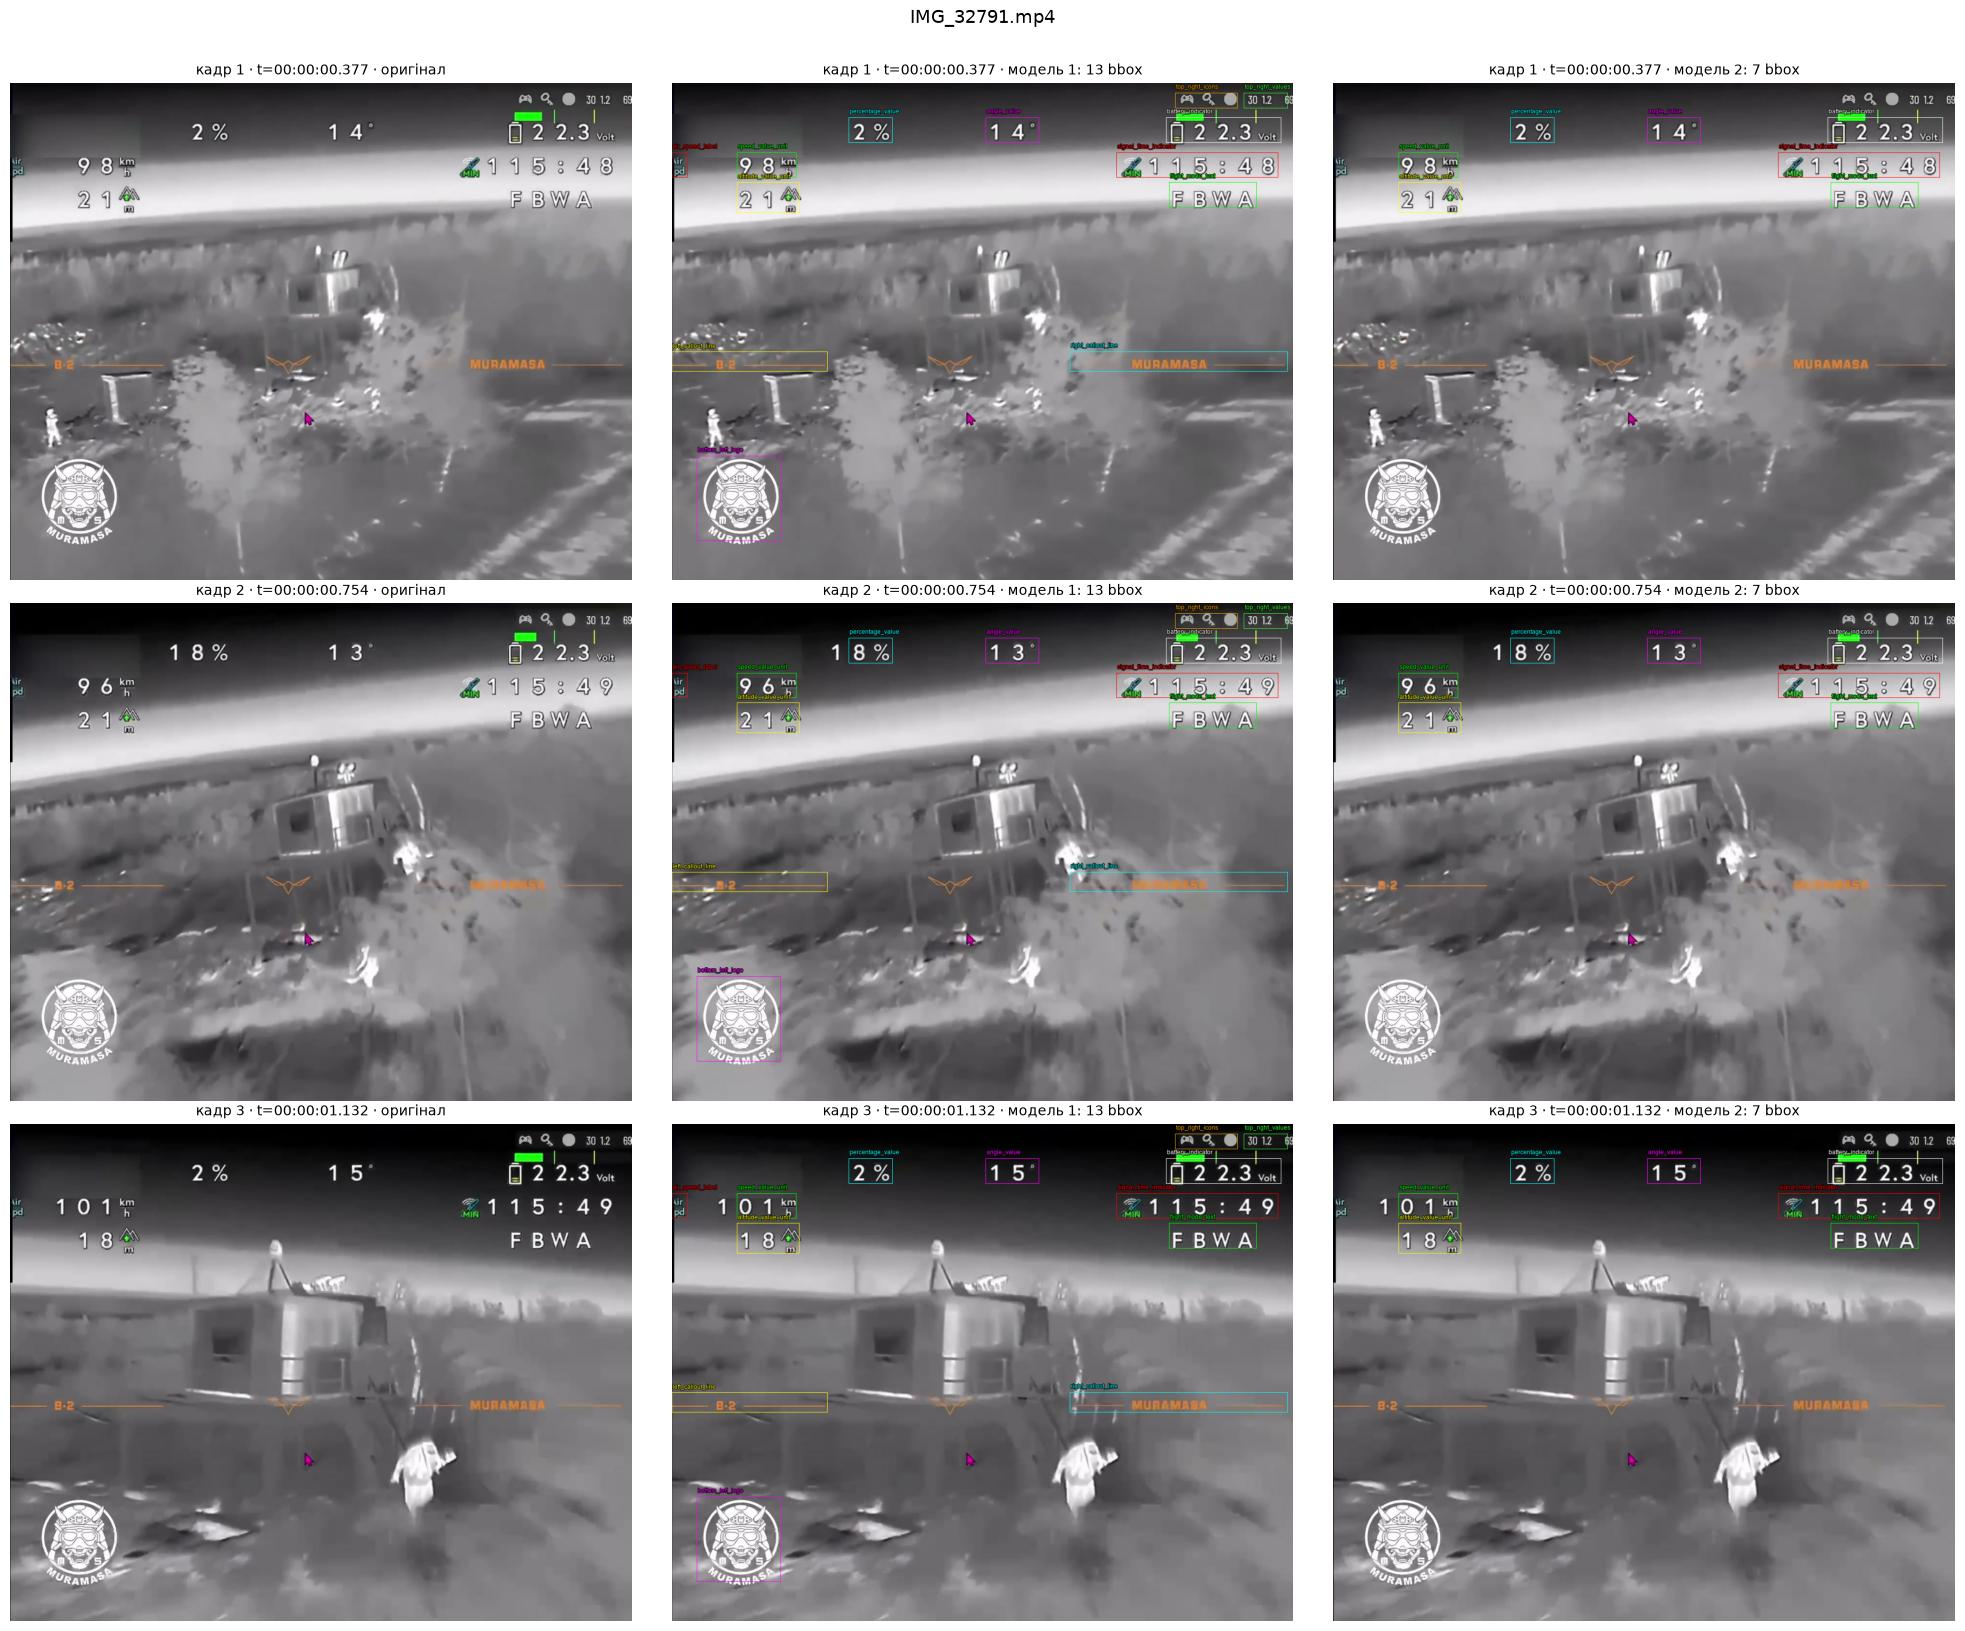

📋 словник моделі 2 без all-null ключів: 7 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
altitude,21 m,21 m,18 m,altitude_value_unit
heading,14°,13°,15°,angle_value
airspeed,98 km/h,96 km/h,101 km/h,speed_value_unit
osd_timer,115:48,115:49,115:49,signal_time_indicator
flight_mode,FBWA,FBWA,FBWA,flight_mode_text
battery_voltage,22.3 Volt,22.3 Volt,22.3 Volt,battery_indicator
throttle_pct,2 %,18 %,2 %,percentage_value



##############################################################################################################
🎬 IMG_32792.mp4 · bbox: модель 1 = 12, модель 2 = 7 · ран м1 #0, ран м2 #0 · повний час пайплайну 93.9 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,62.49,0.002134
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,30.86,0.001739
разом (м1 + м2),,2,2,93.35,0.003873


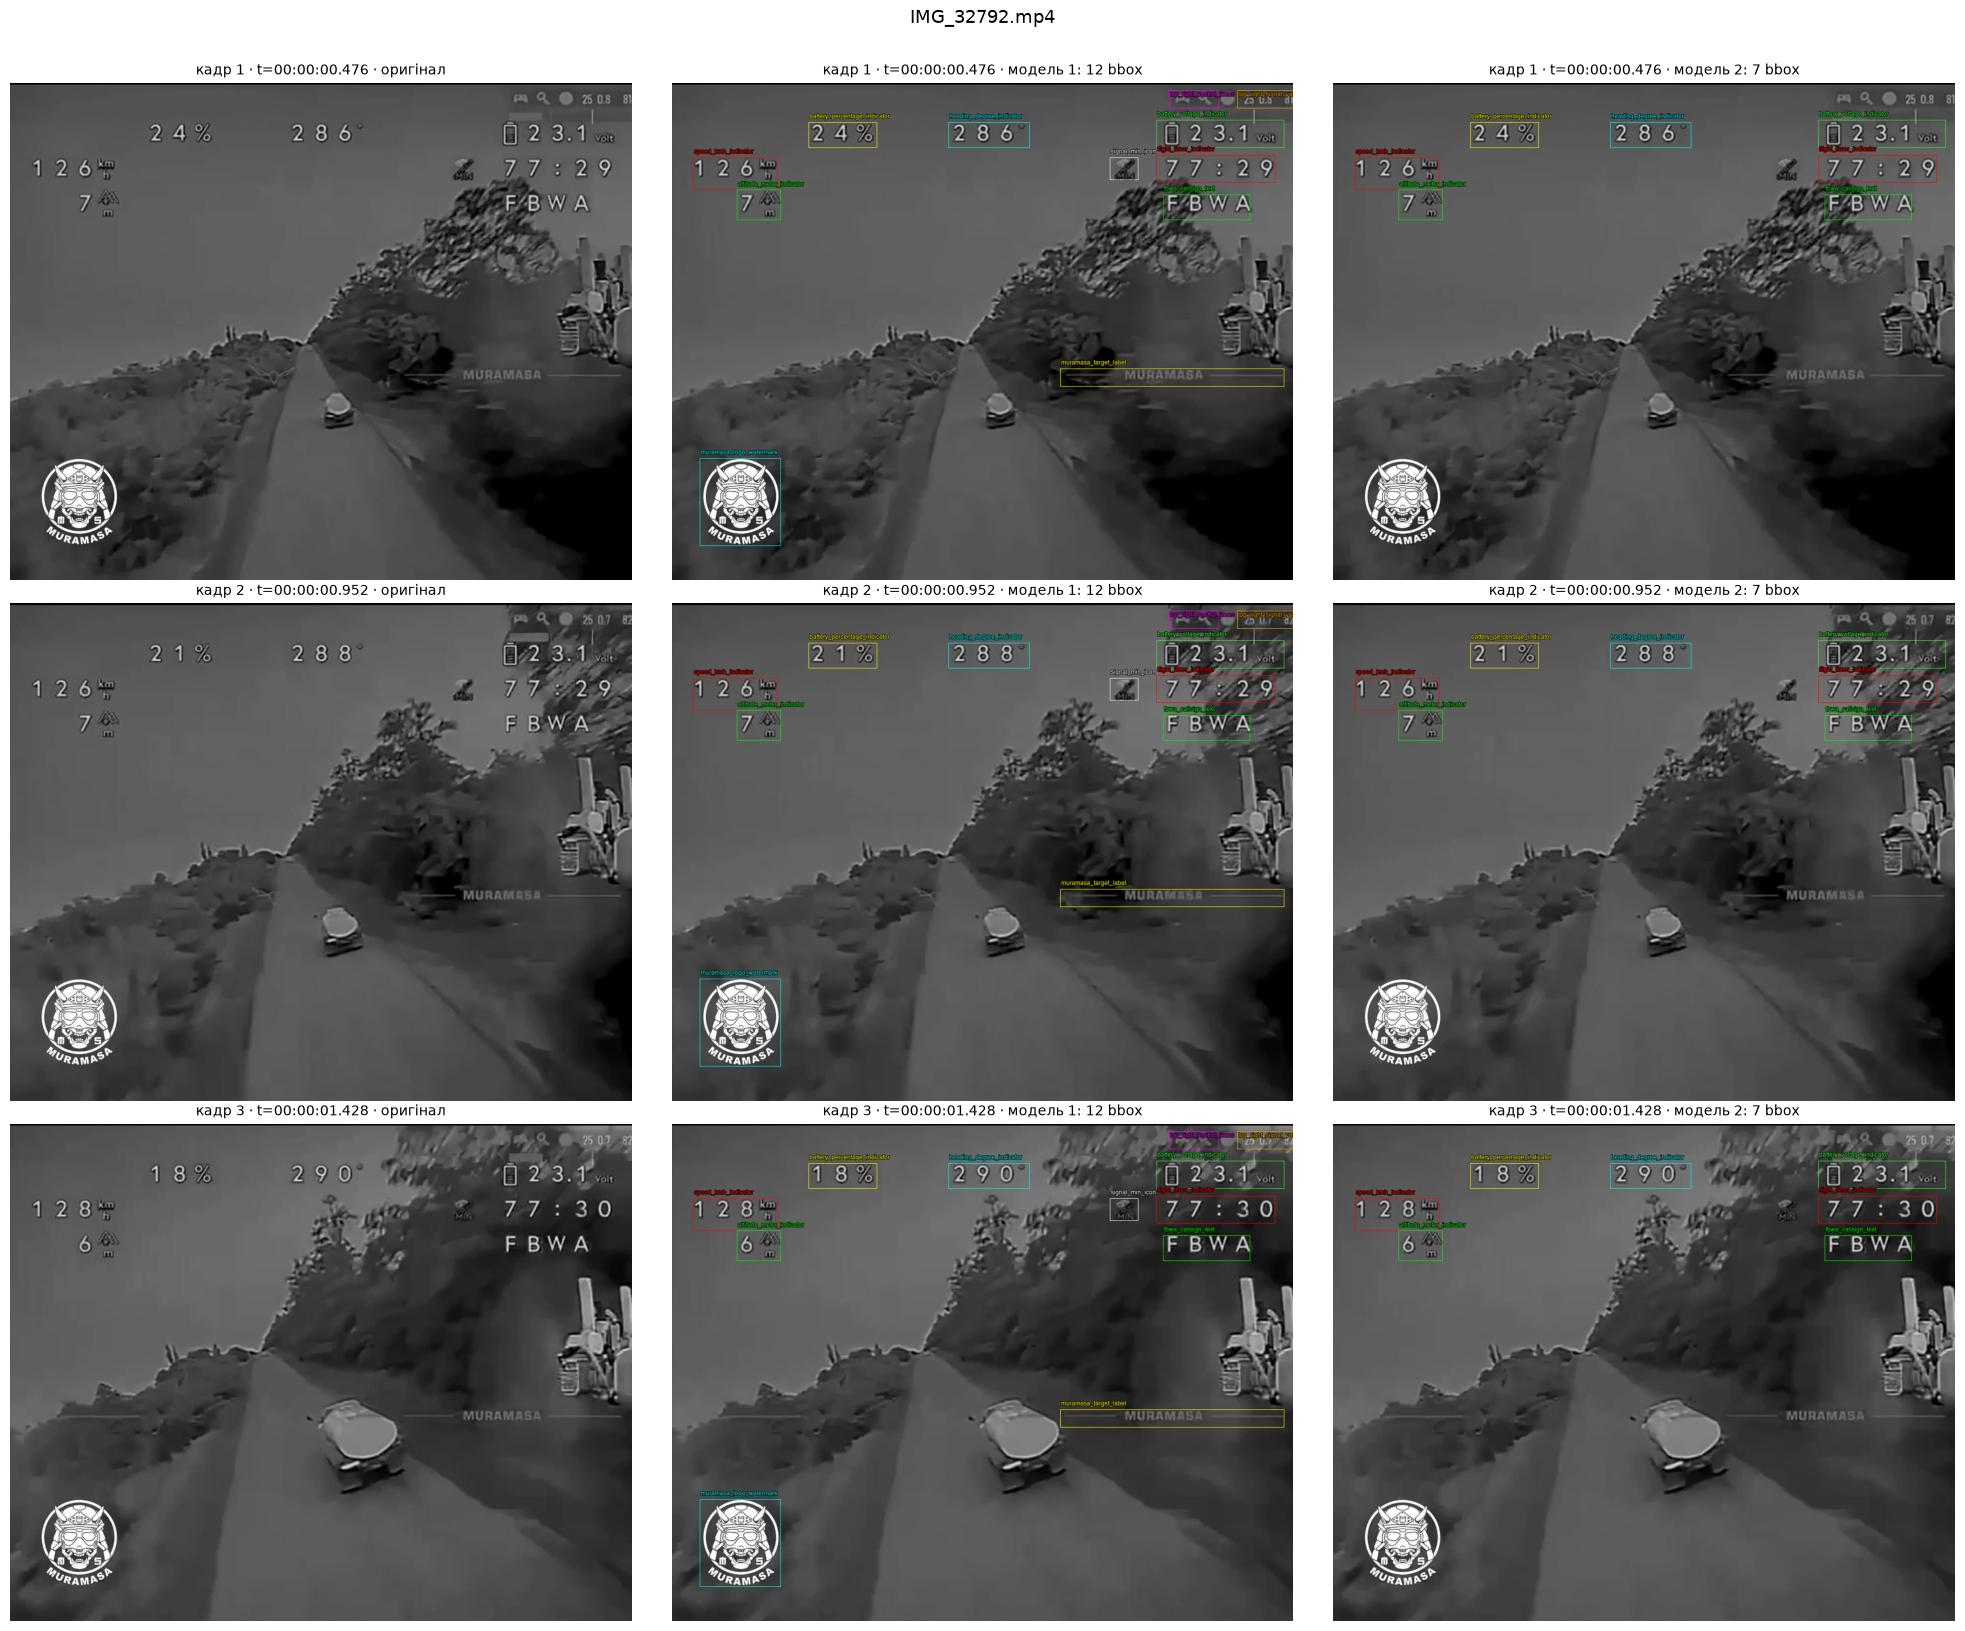

📋 словник моделі 2 без all-null ключів: 8 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
altitude,7 m,7 m,6 m,altitude_meter_indicator
altitude_reference,relative,relative,relative,altitude_meter_indicator
heading,286°,288°,290°,heading_degree_indicator
speed,126 km/h,126 km/h,128 km/h,speed_kmh_indicator
flight_time,77:29,77:29,77:30,flight_timer_indicator
flight_mode,FBWA,FBWA,FBWA,fbwa_callsign_text
battery_voltage,23.1 Volt,23.1 Volt,23.1 Volt,battery_voltage_indicator
battery_remaining_pct,24%,21%,18%,battery_percentage_indicator



##############################################################################################################
🎬 IMG_37871.mp4 · bbox: модель 1 = 8, модель 2 = 5 · ран м1 #0, ран м2 #0 · повний час пайплайну 276.6 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,66.32,0.001920
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,209.75,0.006025
разом (м1 + м2),,2,2,276.07,0.007945


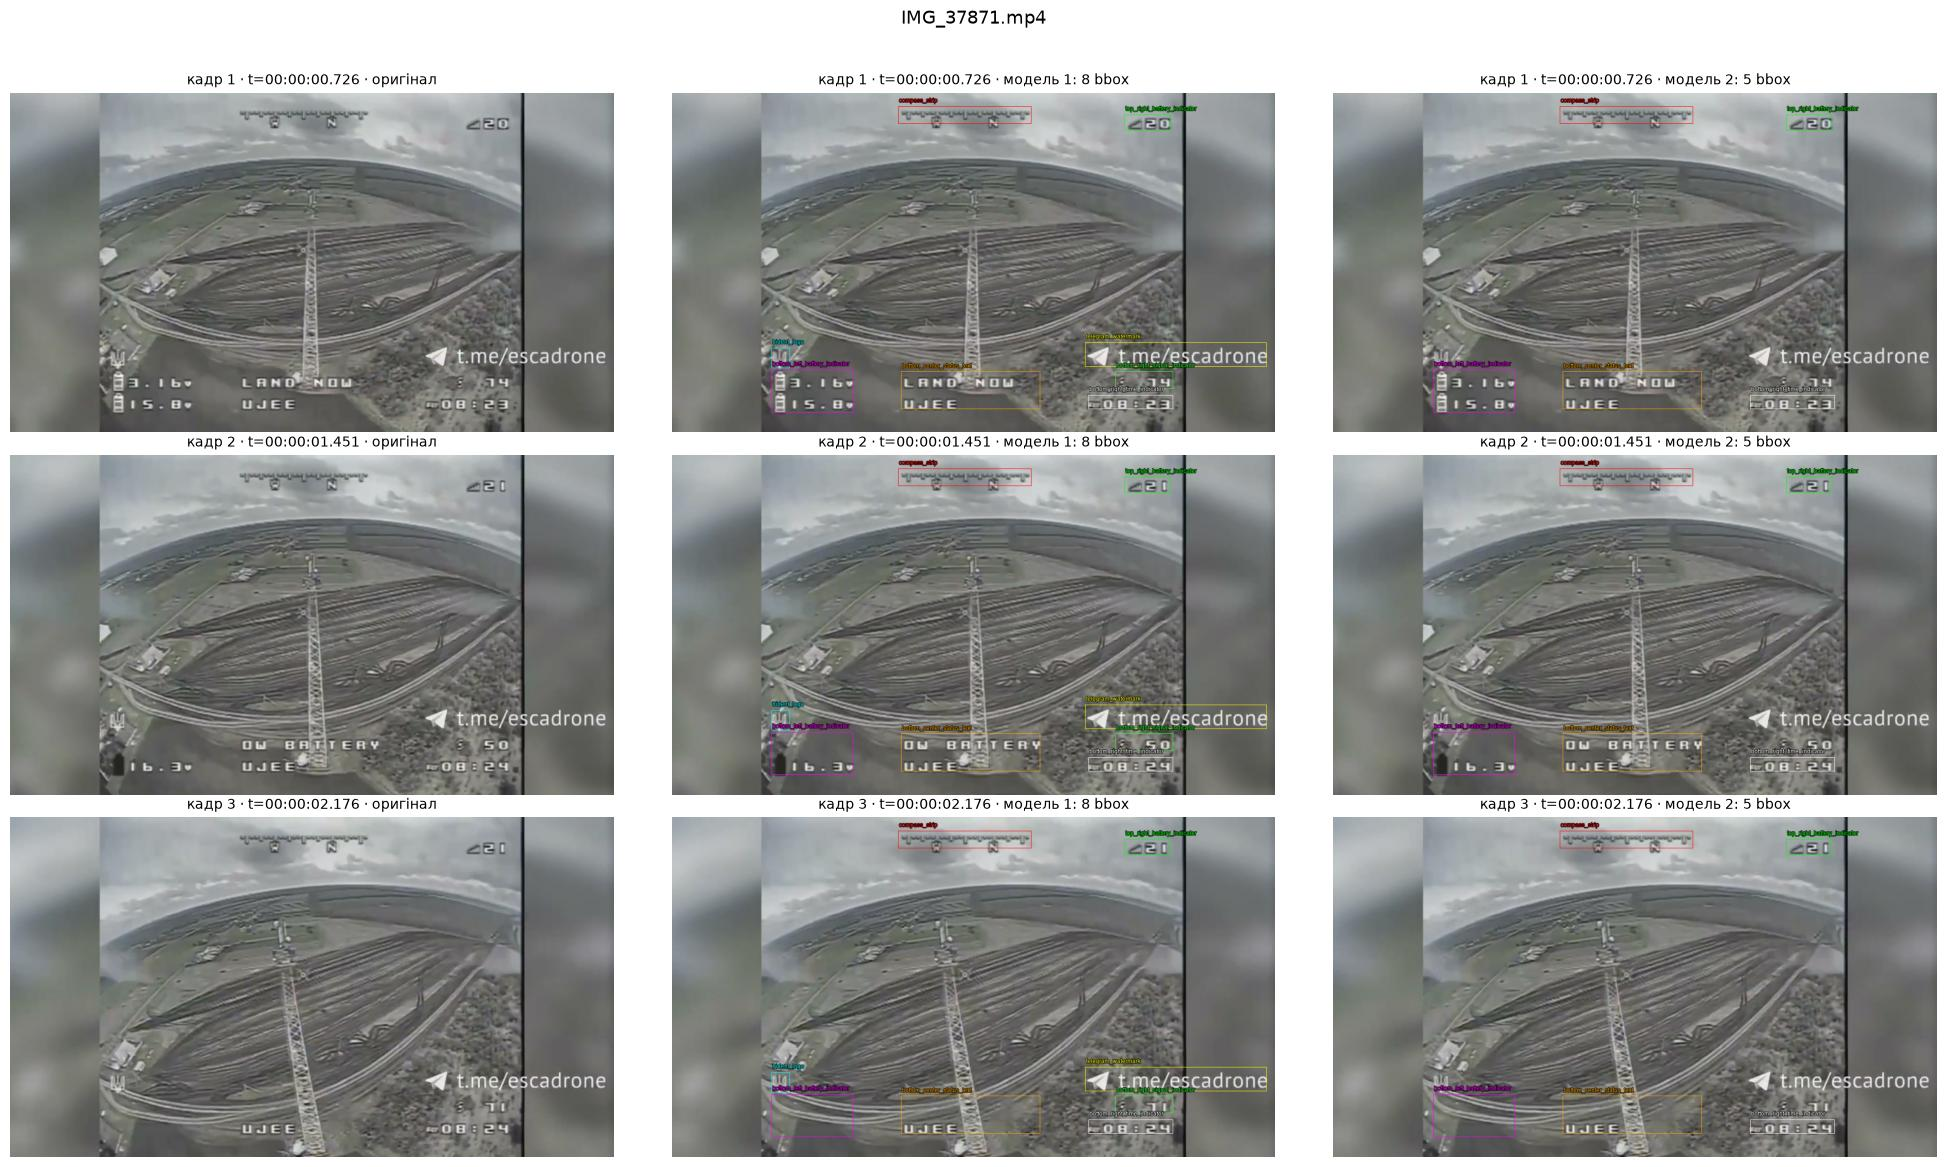

📋 словник моделі 2 без all-null ключів: 6 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
heading,315°,315°,315°,compass_strip
osd_clock_time,08:23,08:24,08:24,bottom_right_time_indicator
battery_voltage,15.8 V,16.3 V,null,bottom_left_battery_indicator
cell_voltage,3.16 V,null,null,bottom_left_battery_indicator
battery_remaining_pct,20,21,21,top_right_battery_indicator
warnings,LAND NOW,LOW BATTERY,null,bottom_center_status_text



##############################################################################################################
🎬 IMG_37872.mp4 · bbox: модель 1 = 11, модель 2 = 6 · ран м1 #0, ран м2 #0 · повний час пайплайну 143.6 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,51.95,0.001874
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,91.35,0.003671
разом (м1 + м2),,2,2,143.30,0.005545


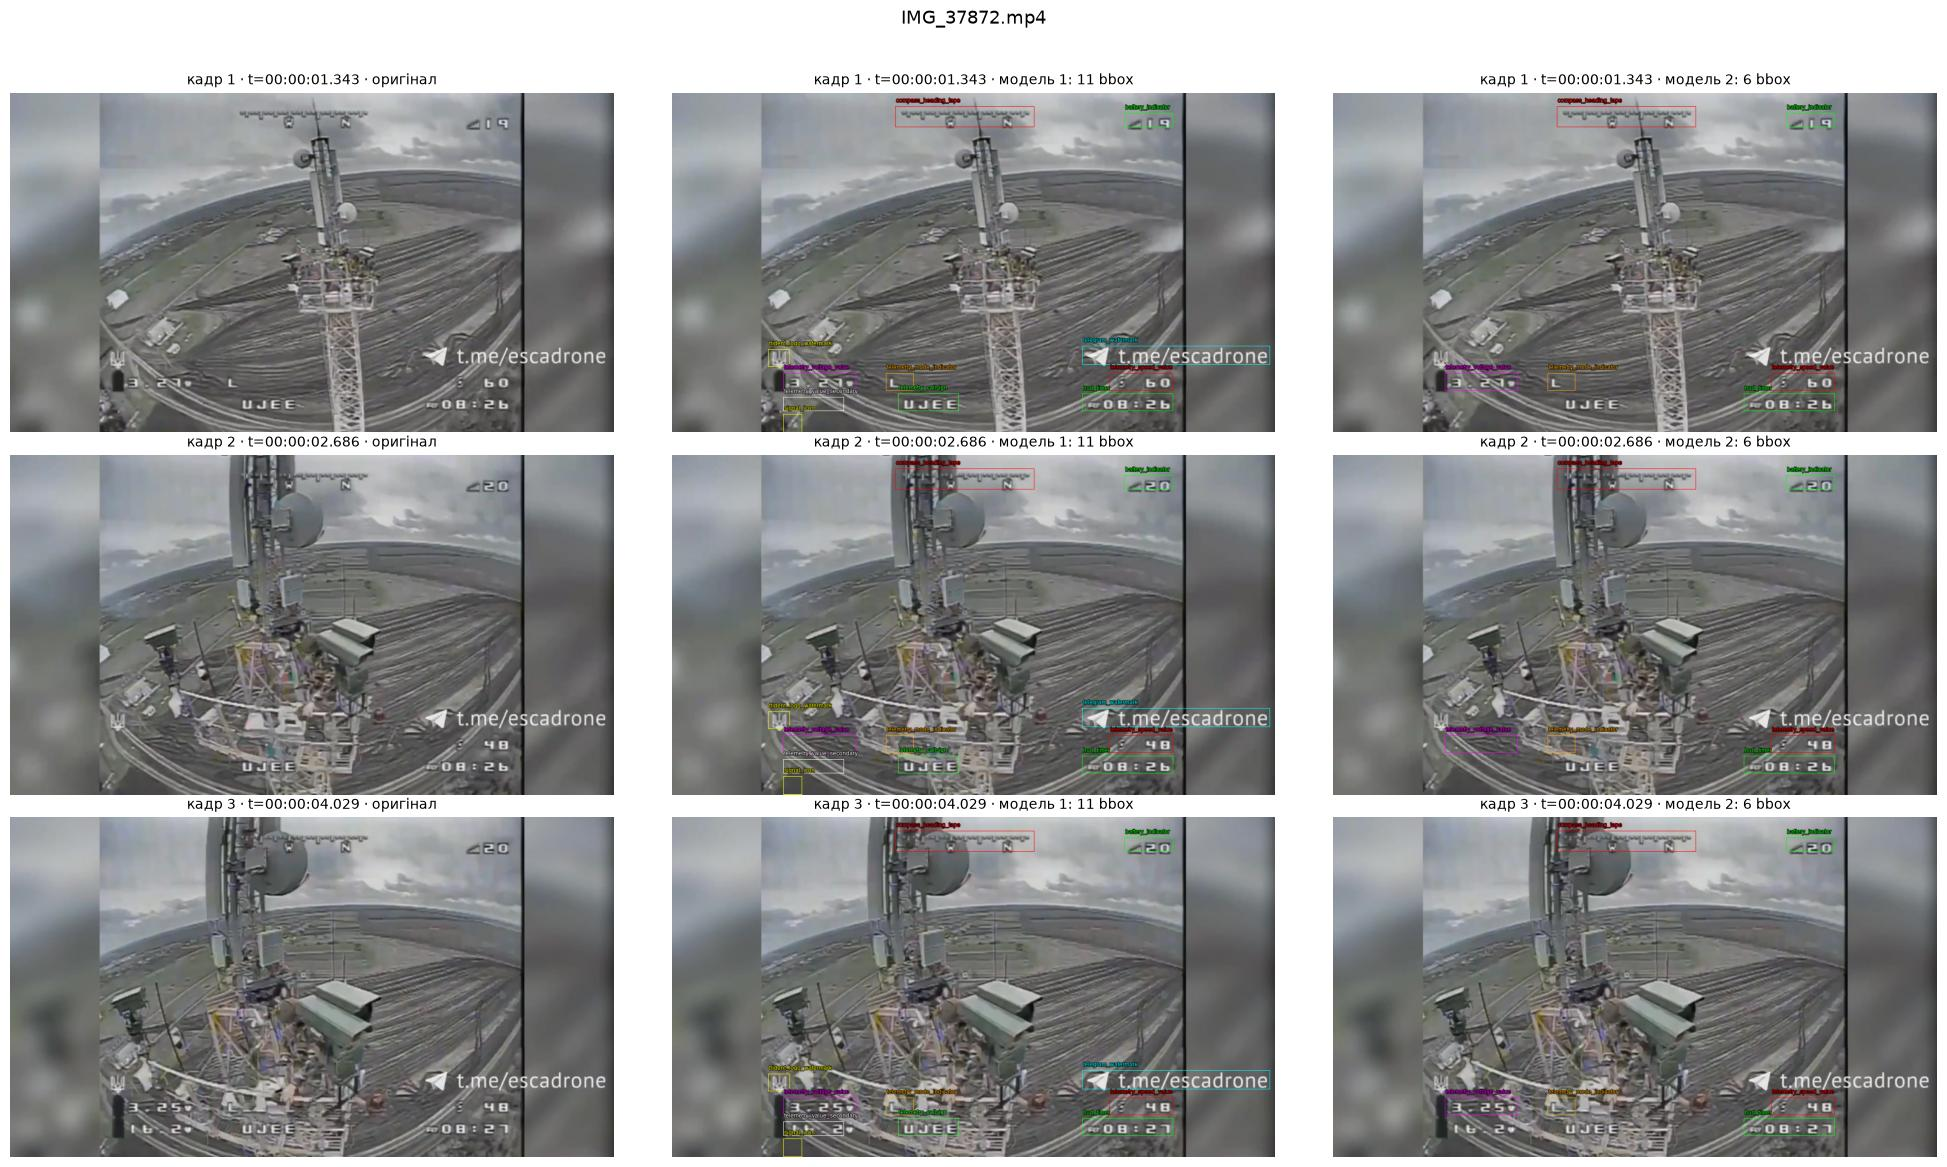

📋 словник моделі 2 без all-null ключів: 6 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
heading,295°,285°,250°,compass_heading_tape
speed,60,48,48,telemetry_speed_value
osd_timer,08:26,08:26,08:27,hud_timer
flight_mode,L,L,L,telemetry_mode_indicator
battery_voltage,19,20,20,battery_indicator
cell_voltage,3.27,null,3.25,telemetry_voltage_value



##############################################################################################################
🎬 IMG_3812.MP4 · bbox: модель 1 = 9, модель 2 = 5 · ран м1 #0, ран м2 #0 · повний час пайплайну 193.1 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,39.07,0.001105
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,153.64,0.005164
разом (м1 + м2),,2,2,192.71,0.006269


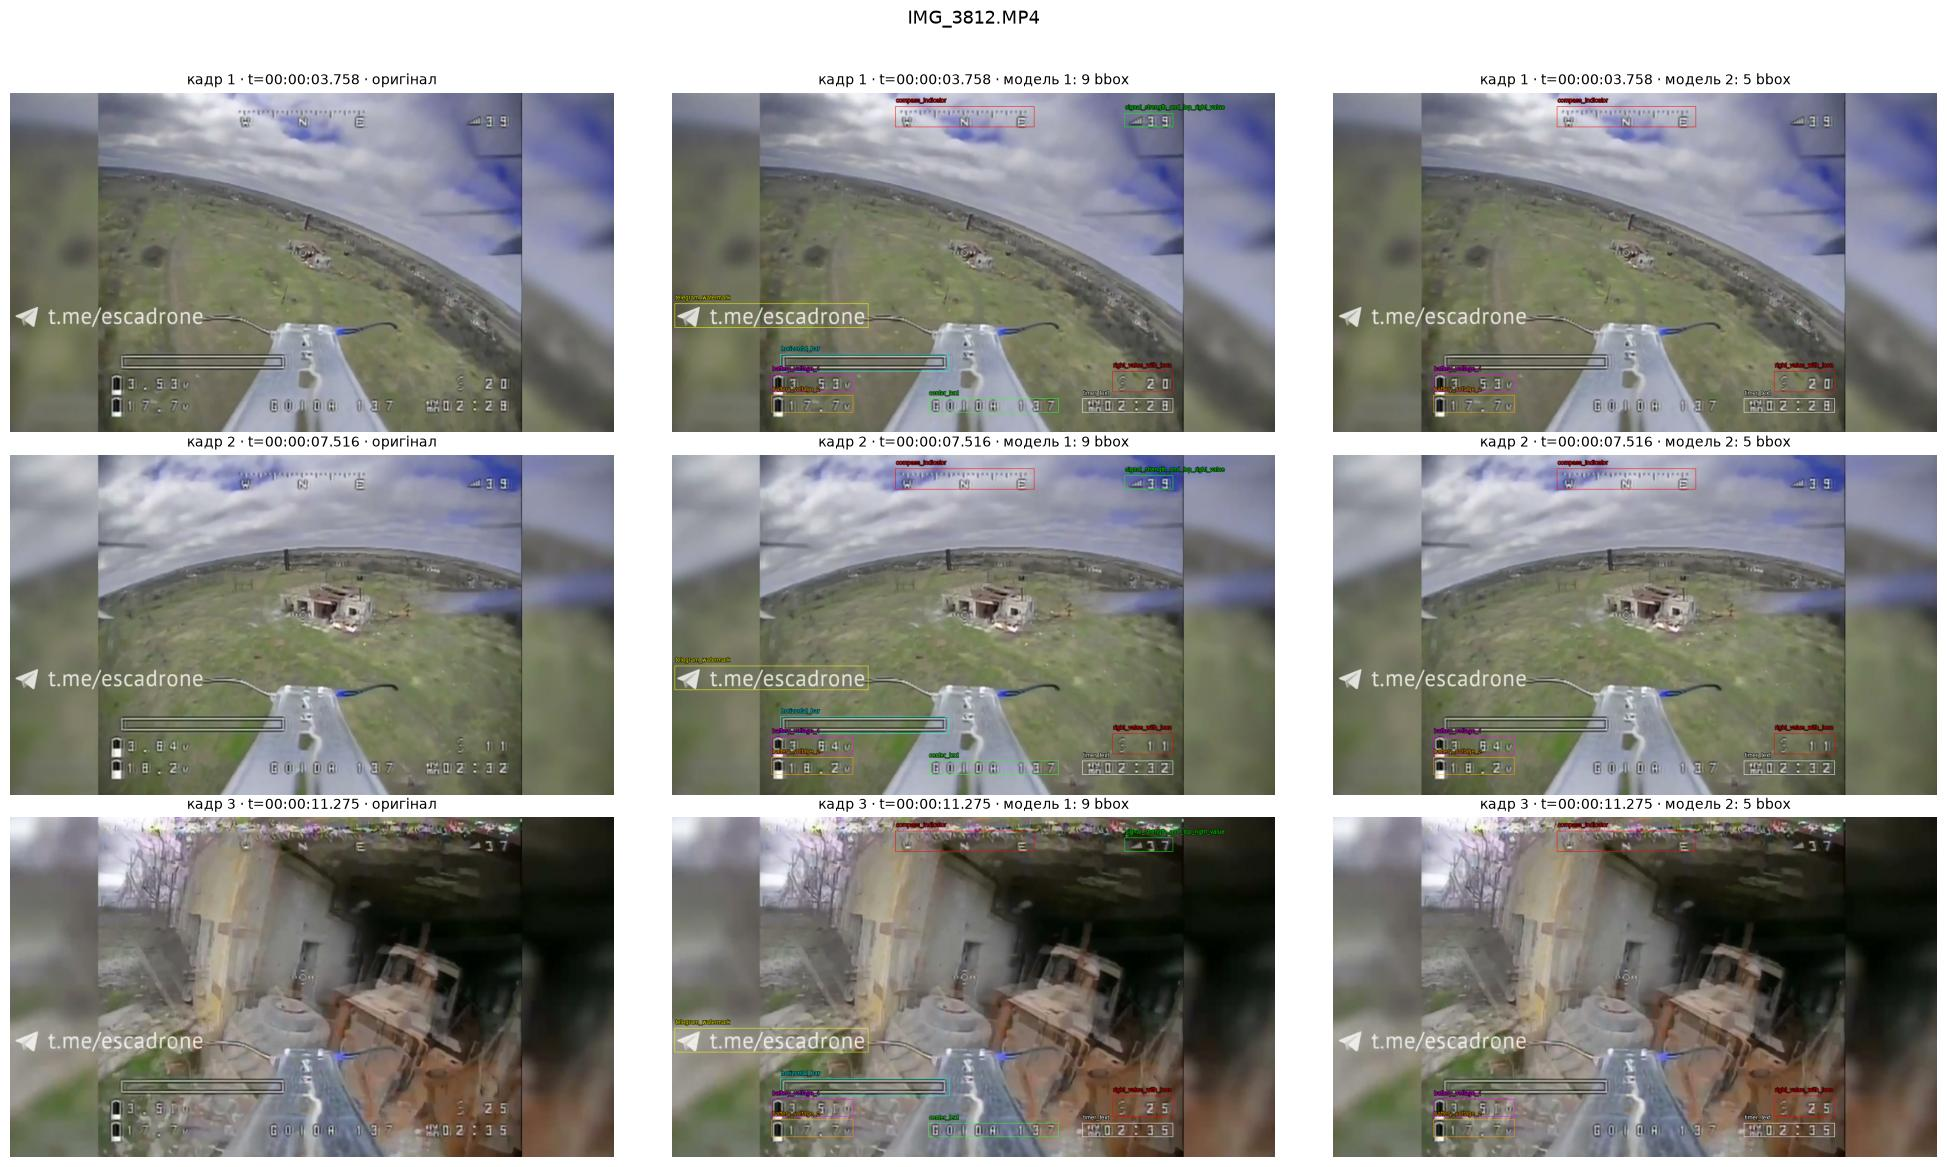

📋 словник моделі 2 без all-null ключів: 5 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
heading,0°,0°,0°,compass_indicator
distance_to_home,20,11,25,right_value_with_icon
flight_time,02:28,02:32,02:35,timer_text
battery_voltage,17.7 v,18.2 v,17.7 v,battery_voltage_2
cell_voltage,3.53 v,3.64 v,3.50 v,battery_voltage_1



##############################################################################################################
🎬 IMG_4583.MOV · bbox: модель 1 = 29, модель 2 = 7 · ран м1 #0, ран м2 #0 · повний час пайплайну 150.7 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,91.49,0.002626
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,58.85,0.002486
разом (м1 + м2),,2,2,150.34,0.005112


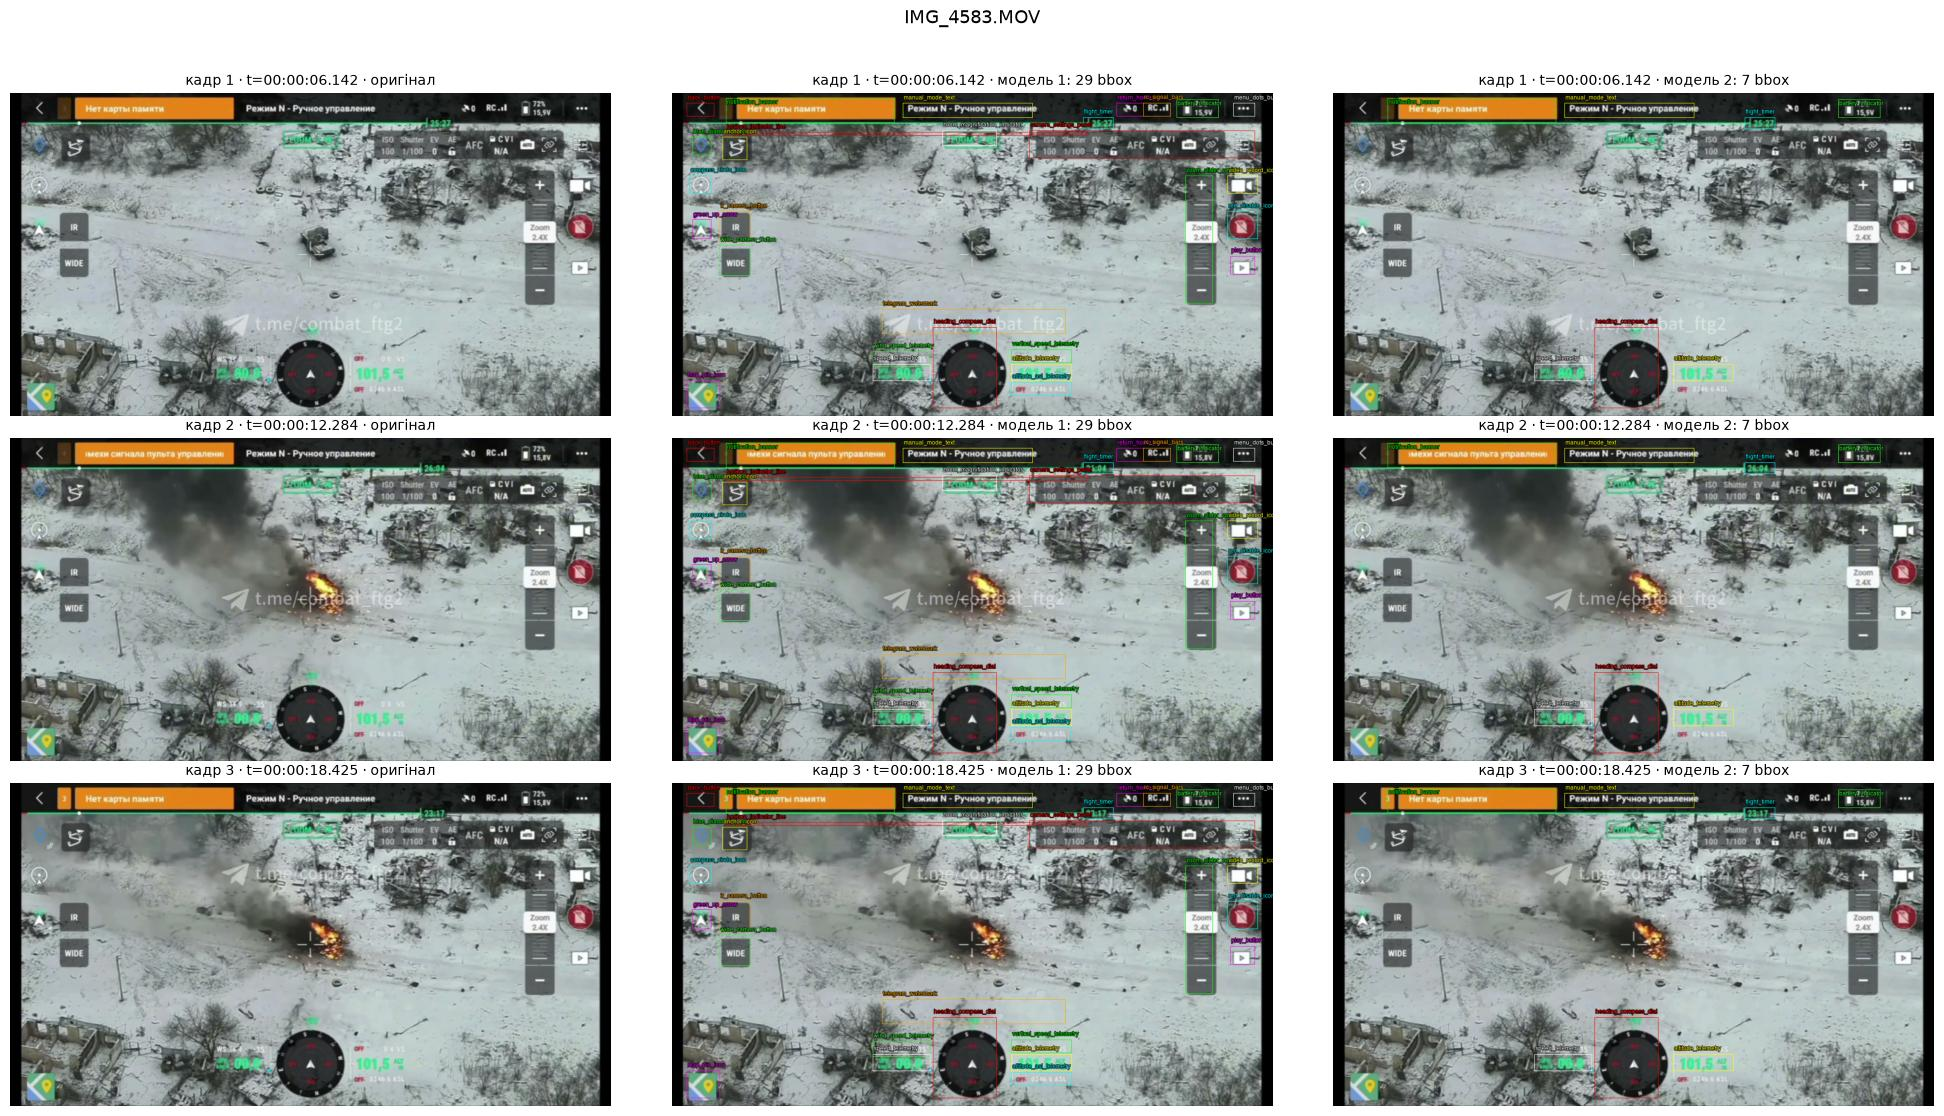

📋 словник моделі 2 без all-null ключів: 7 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
altitude,101.5 m,101.5 m,101.5 m,altitude_telemetry
heading,0°,0°,0°,heading_compass_dial
speed,00.0,00.0,00.0,speed_telemetry
flight_time,25:27,21:04,23:17,flight_timer
flight_mode,Режим N - Ручное управление,Режим N - Ручное управление,Режим N - Ручное управление,manual_mode_text
battery_voltage,"15,9V","15,8V","15,8V",battery_indicator
warnings,Нет карты памяти,помехи сигнала пульта управления,Нет карты памяти,notification_banner



##############################################################################################################
🎬 IMG_95373.mp4 · bbox: модель 1 = 9, модель 2 = 5 · ран м1 #0, ран м2 #0 · повний час пайплайну 222.9 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,68.4,0.001627
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,154.1,0.004561
разом (м1 + м2),,2,2,222.5,0.006188


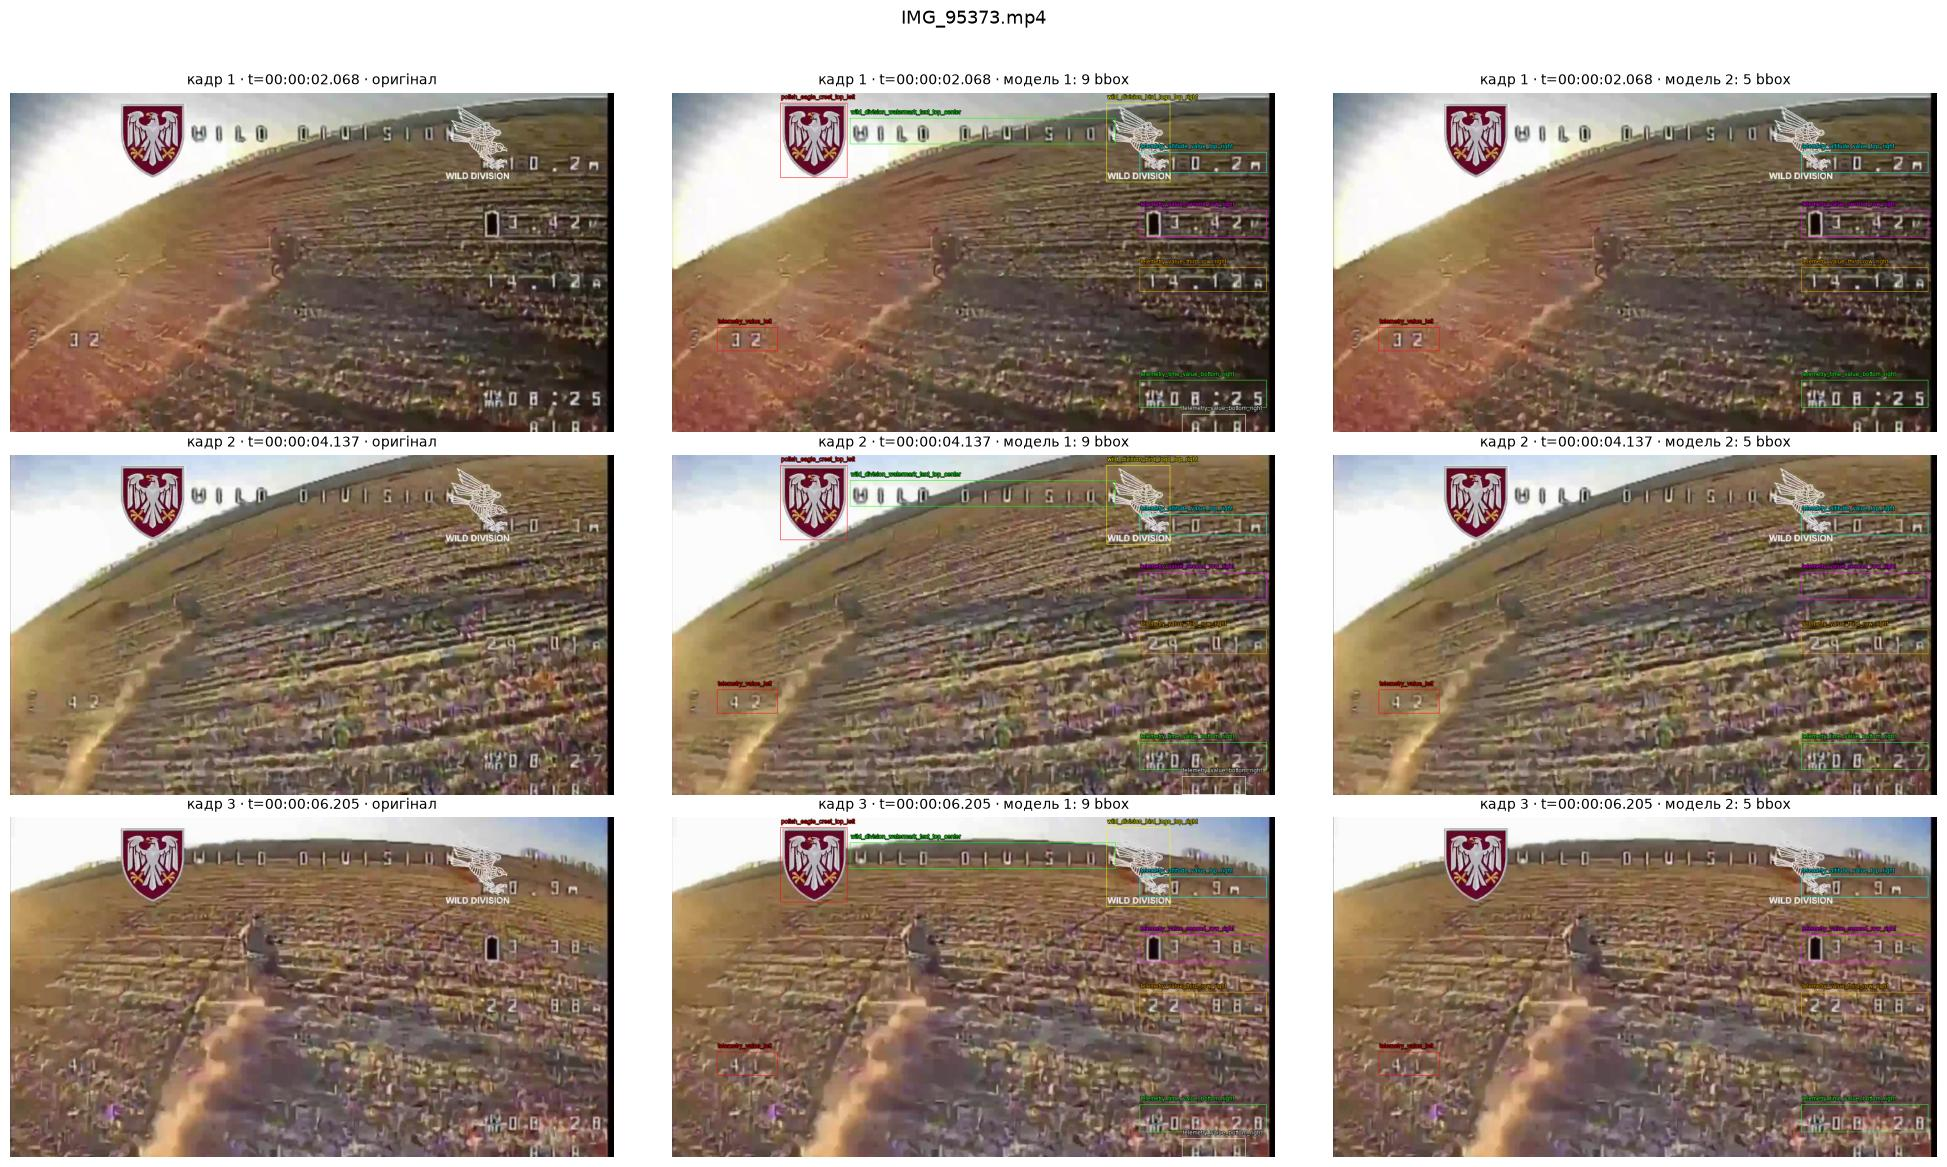

📋 словник моделі 2 без all-null ключів: 5 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
altitude,10.2m,10.1m,10.9m,telemetry_altitude_value_top_right
speed,32,42,4,telemetry_value_left
osd_timer,00:25,00:25,00:28,telemetry_time_value_bottom_right
cell_voltage,3.42V,null,3.30V,telemetry_value_second_row_right
battery_current,14.12A,29.01A,22.88A,telemetry_value_third_row_right



##############################################################################################################
🎬 IMG_95381.mp4 · bbox: модель 1 = 12, модель 2 = 6 · ран м1 #0, ран м2 #0 · повний час пайплайну 383.5 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,107.41,0.003575
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,275.64,0.008604
разом (м1 + м2),,2,2,383.05,0.012179


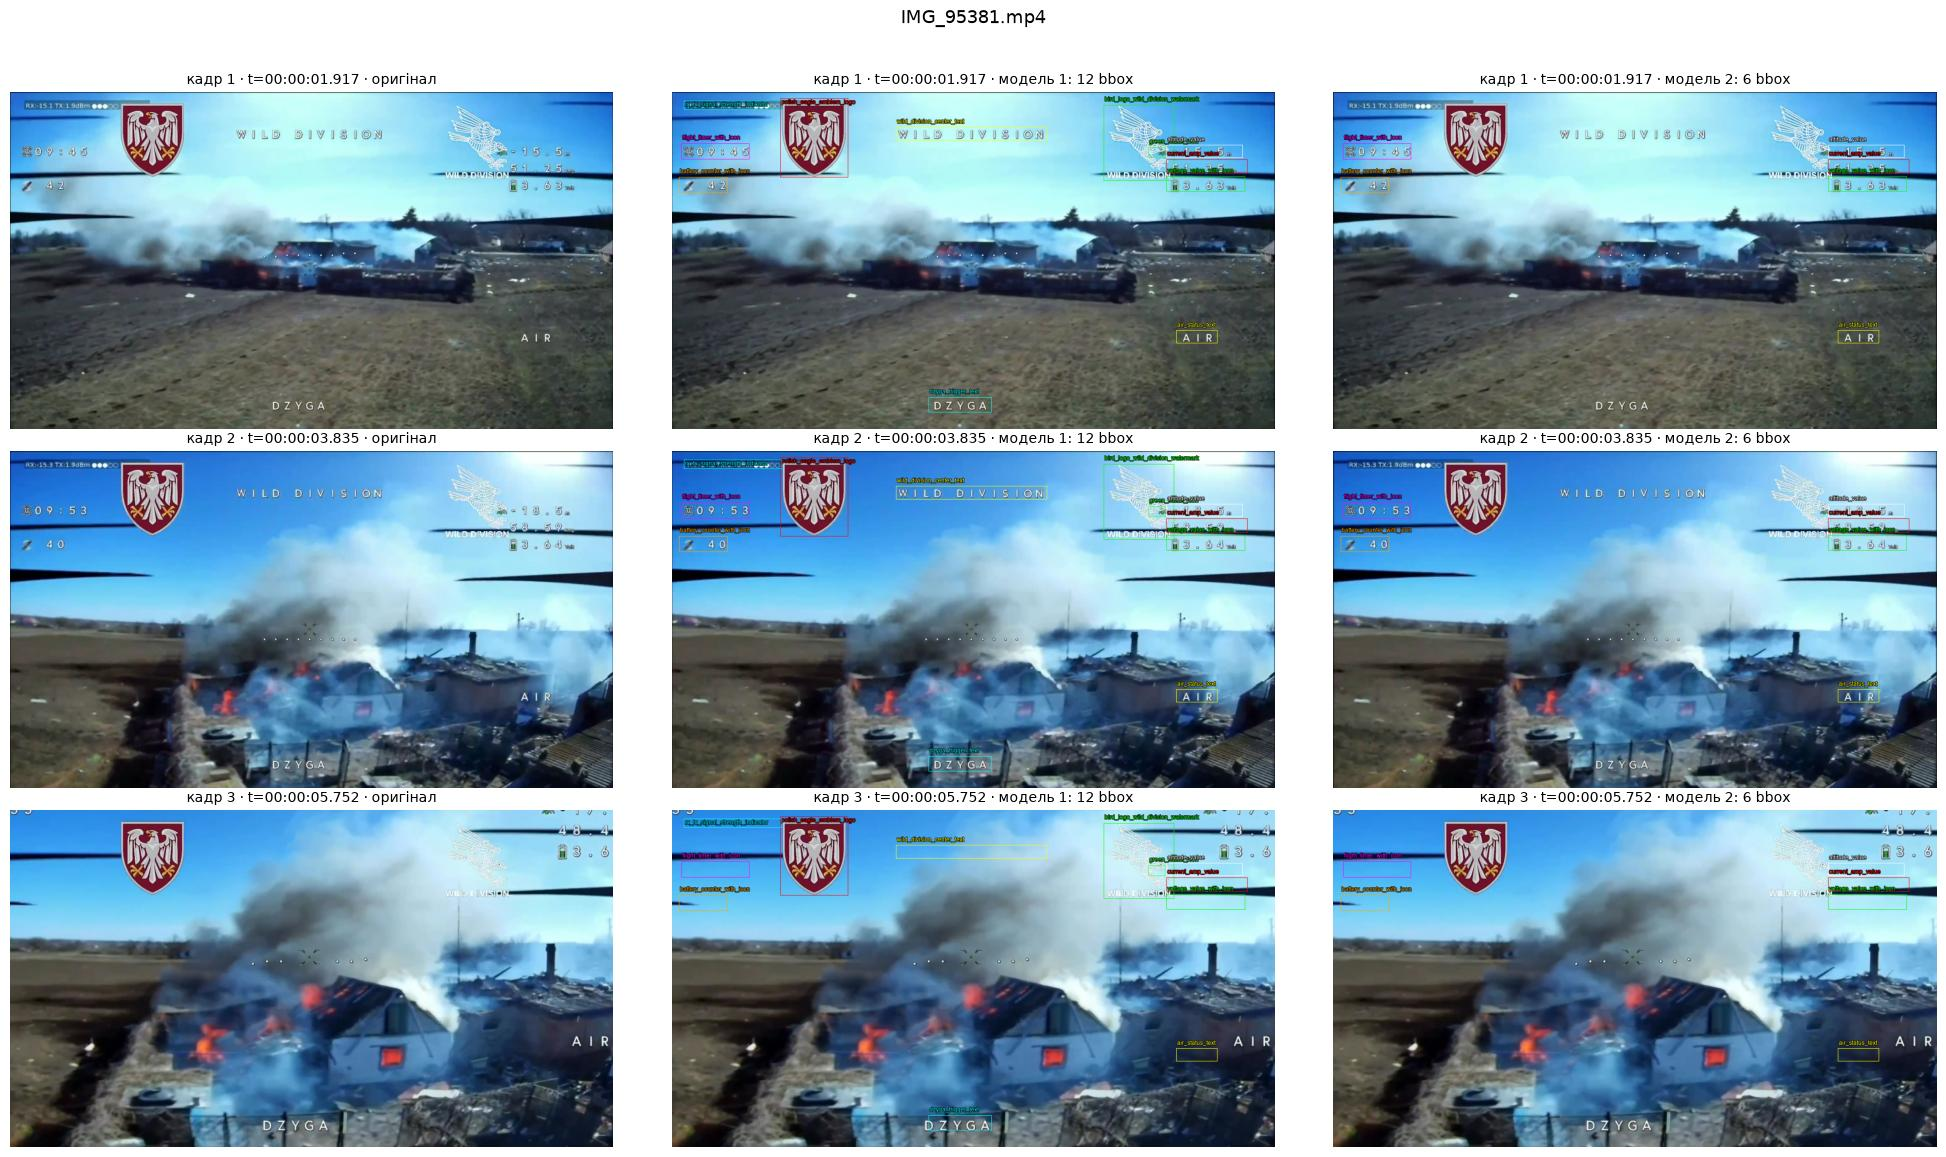

📋 словник моделі 2 без all-null ключів: 6 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
altitude,155 m,185 m,null,altitude_value
flight_time,09:45,09:53,null,flight_timer_with_icon
flight_mode,AIR,AIR,null,air_status_text
battery_voltage,3.63 Volt,3.64 Volt,null,voltage_value_with_icon
battery_remaining_pct,42,40,null,battery_counter_with_icon
battery_current,51.25,58.59,null,current_amp_value



##############################################################################################################
🎬 IMG_95382.mp4 · bbox: модель 1 = 9, модель 2 = 1 · ран м1 #0, ран м2 #0 · повний час пайплайну 285.4 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,91.14,0.000661
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,193.86,0.006348
разом (м1 + м2),,2,2,285.00,0.007009


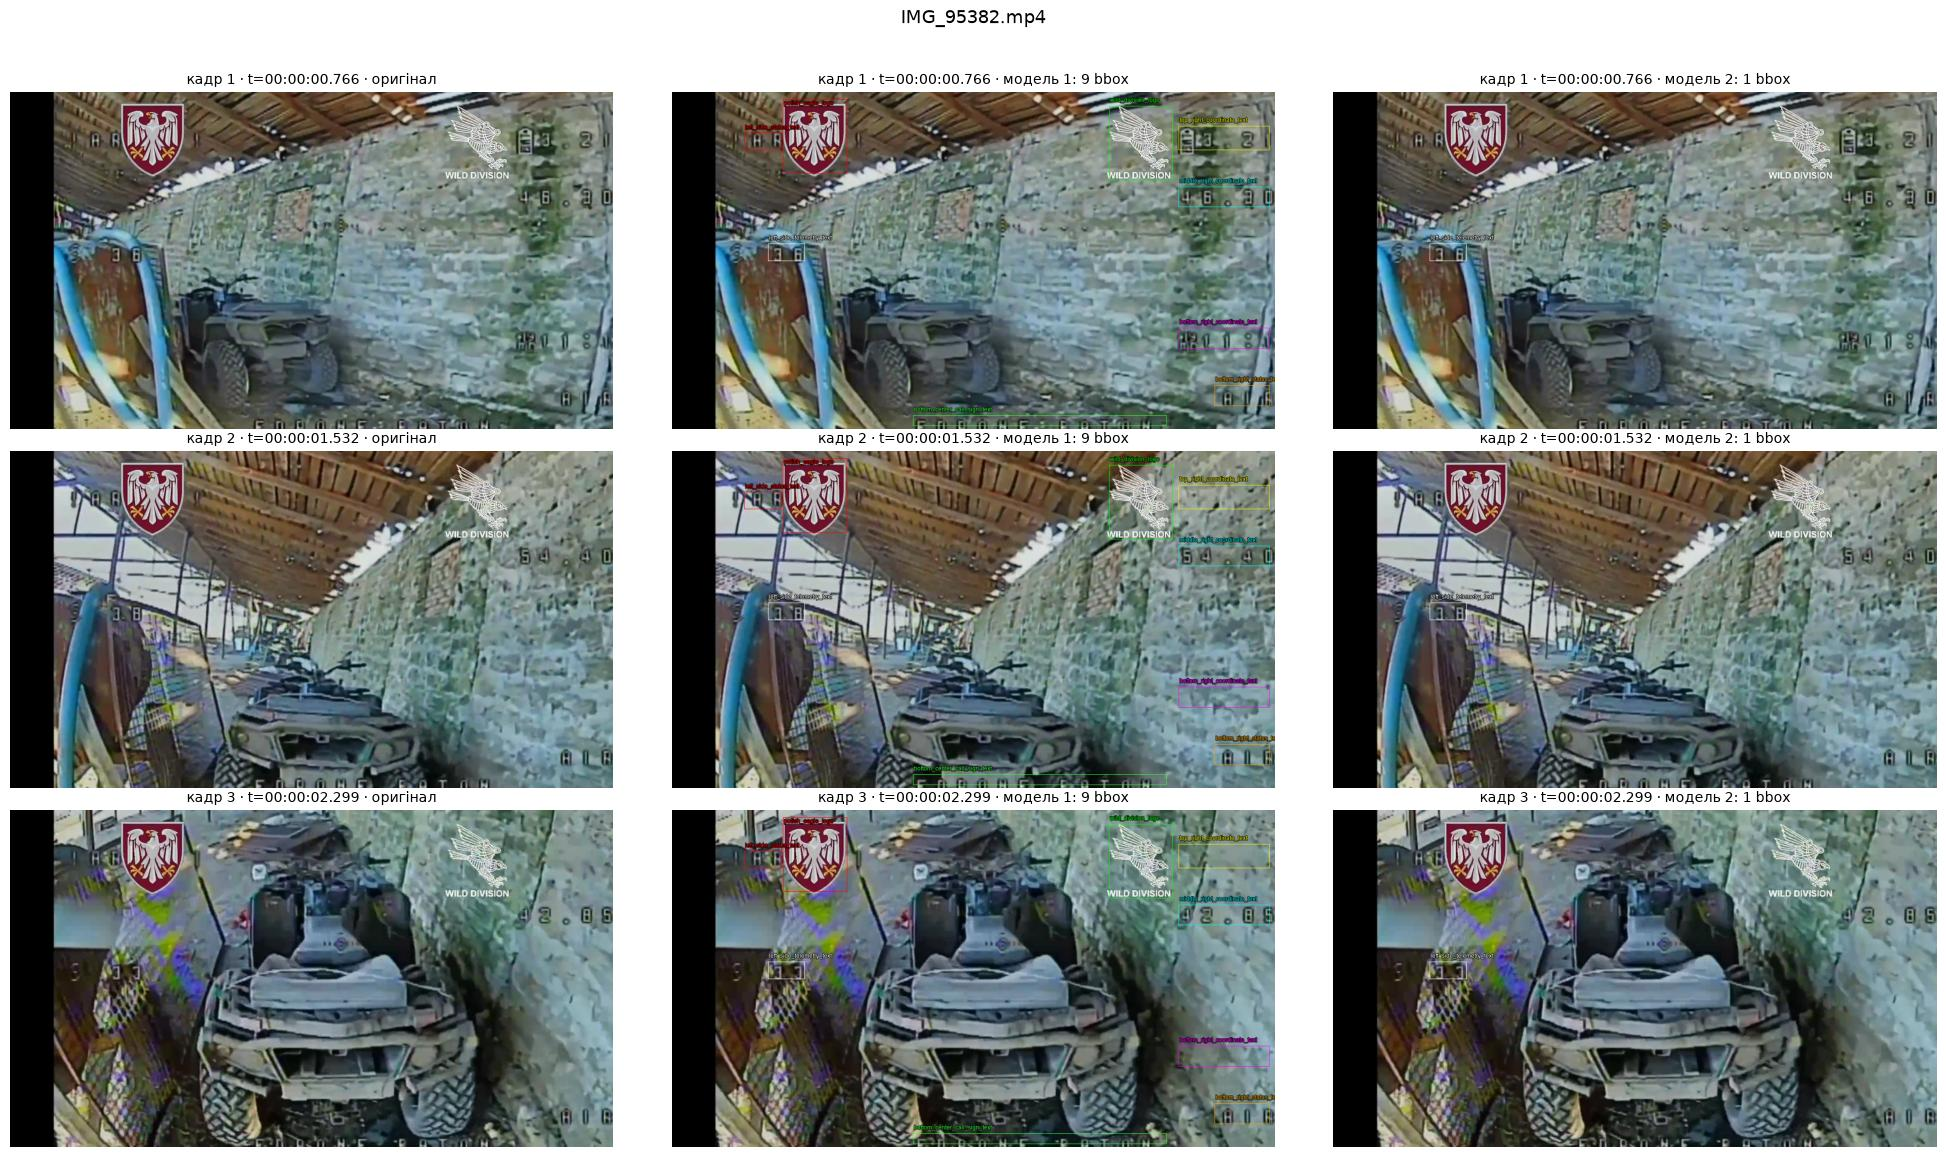

📋 словник моделі 2 без all-null ключів: 1 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
speed,36,38,33,left_side_telemetry_text



##############################################################################################################
🎬 IMG_95383.mp4 · bbox: модель 1 = 6, модель 2 = 4 · ран м1 #0, ран м2 #0 · повний час пайплайну 231.0 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,62.62,0.002371
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,167.99,0.005833
разом (м1 + м2),,2,2,230.61,0.008204


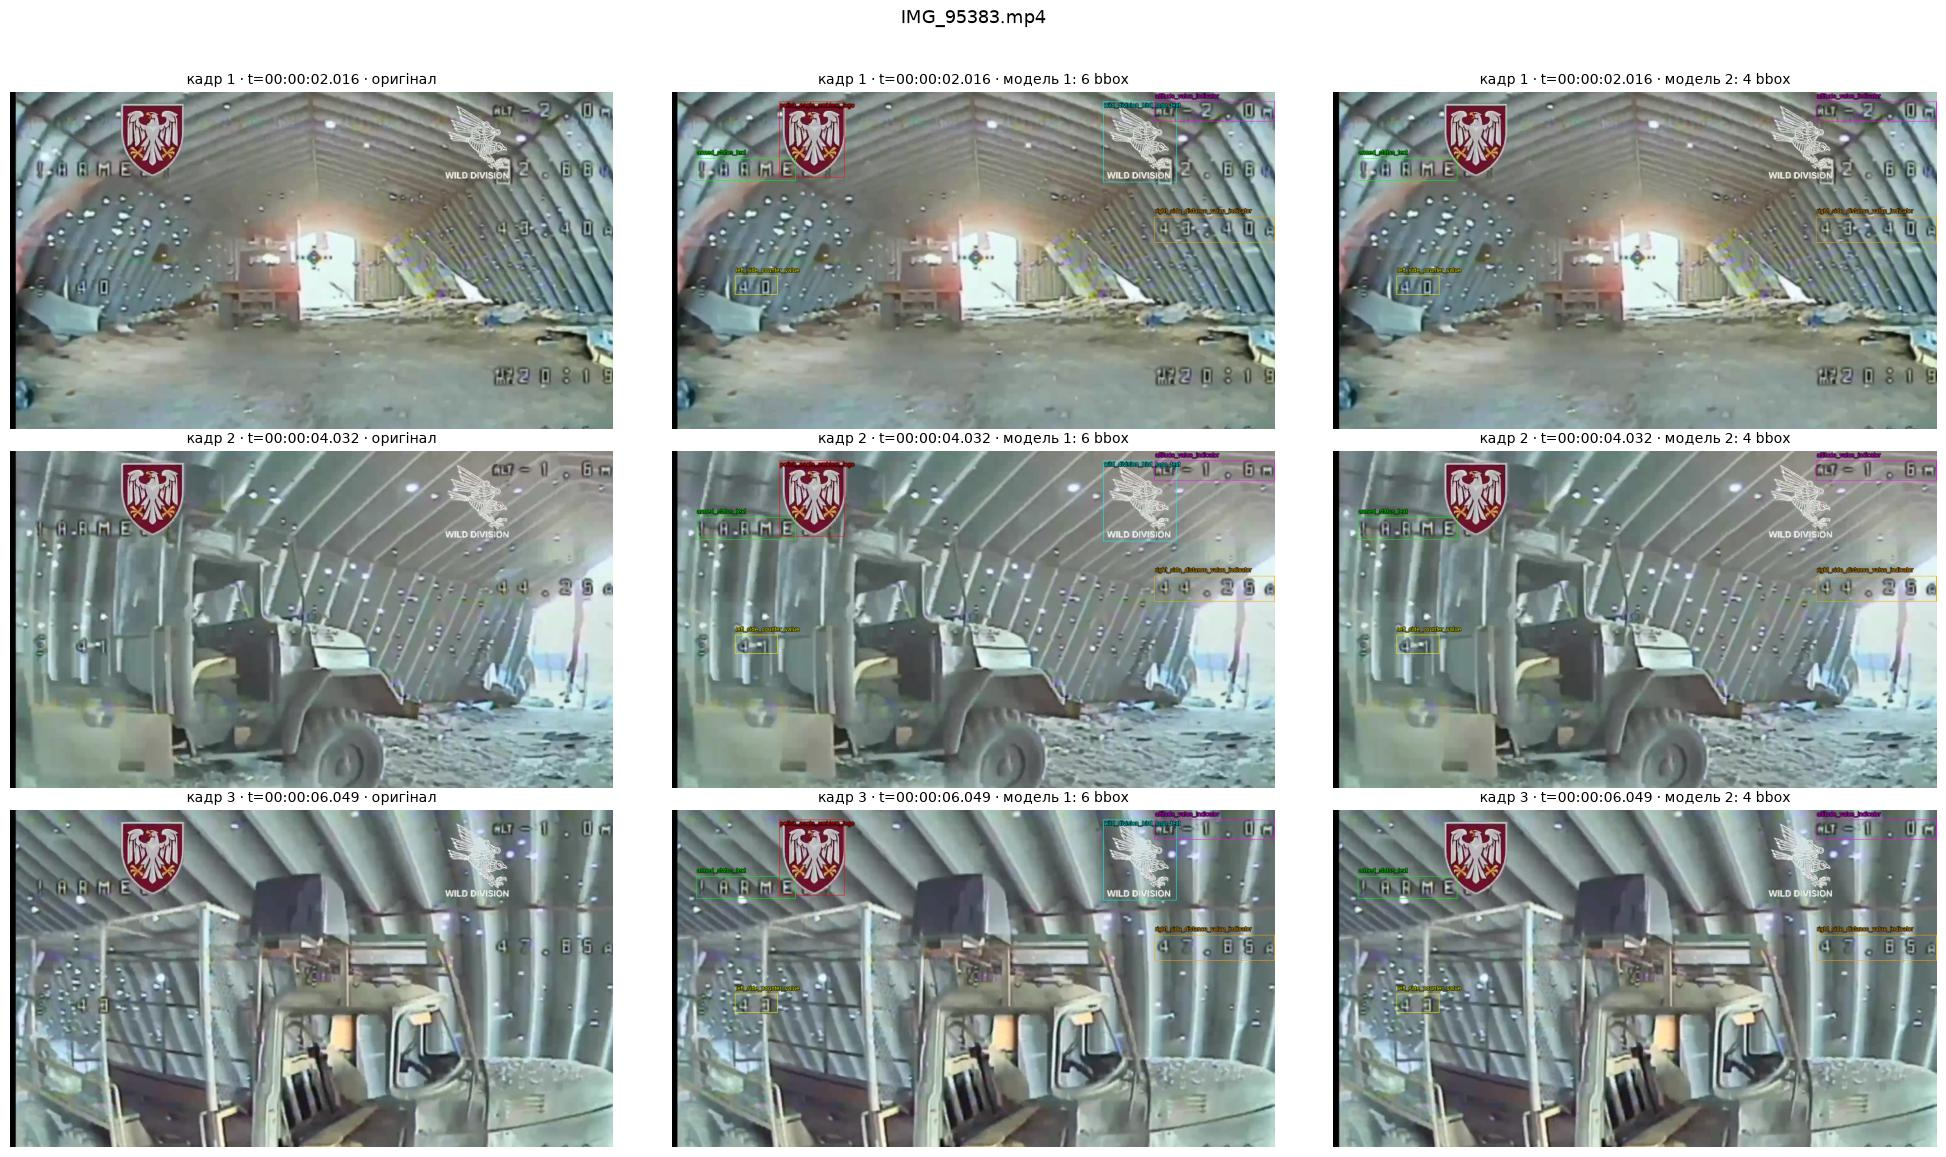

📋 словник моделі 2 без all-null ключів: 4 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
gps_satellites_count,4 0,4 1,4 3,left_side_counter_value
altitude,ALT - 2 . 0 m,ALT - 1 . 6 m,ALT - 1 . 0 m,altitude_value_indicator
distance_to_home,4 3 . 4 0,4 4 . 2 6,4 7 . 8 5,right_side_distance_value_indicator
armed,ARMED,ARMED,ARMED,armed_status_text



##############################################################################################################
🎬 IMG_95384.mp4 · bbox: модель 1 = 6, модель 2 = 0 · ран м1 #0, ран м2 #0 · повний час пайплайну 71.5 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,9.55,0.000224
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,61.51,0.000878
разом (м1 + м2),,2,2,71.06,0.001102


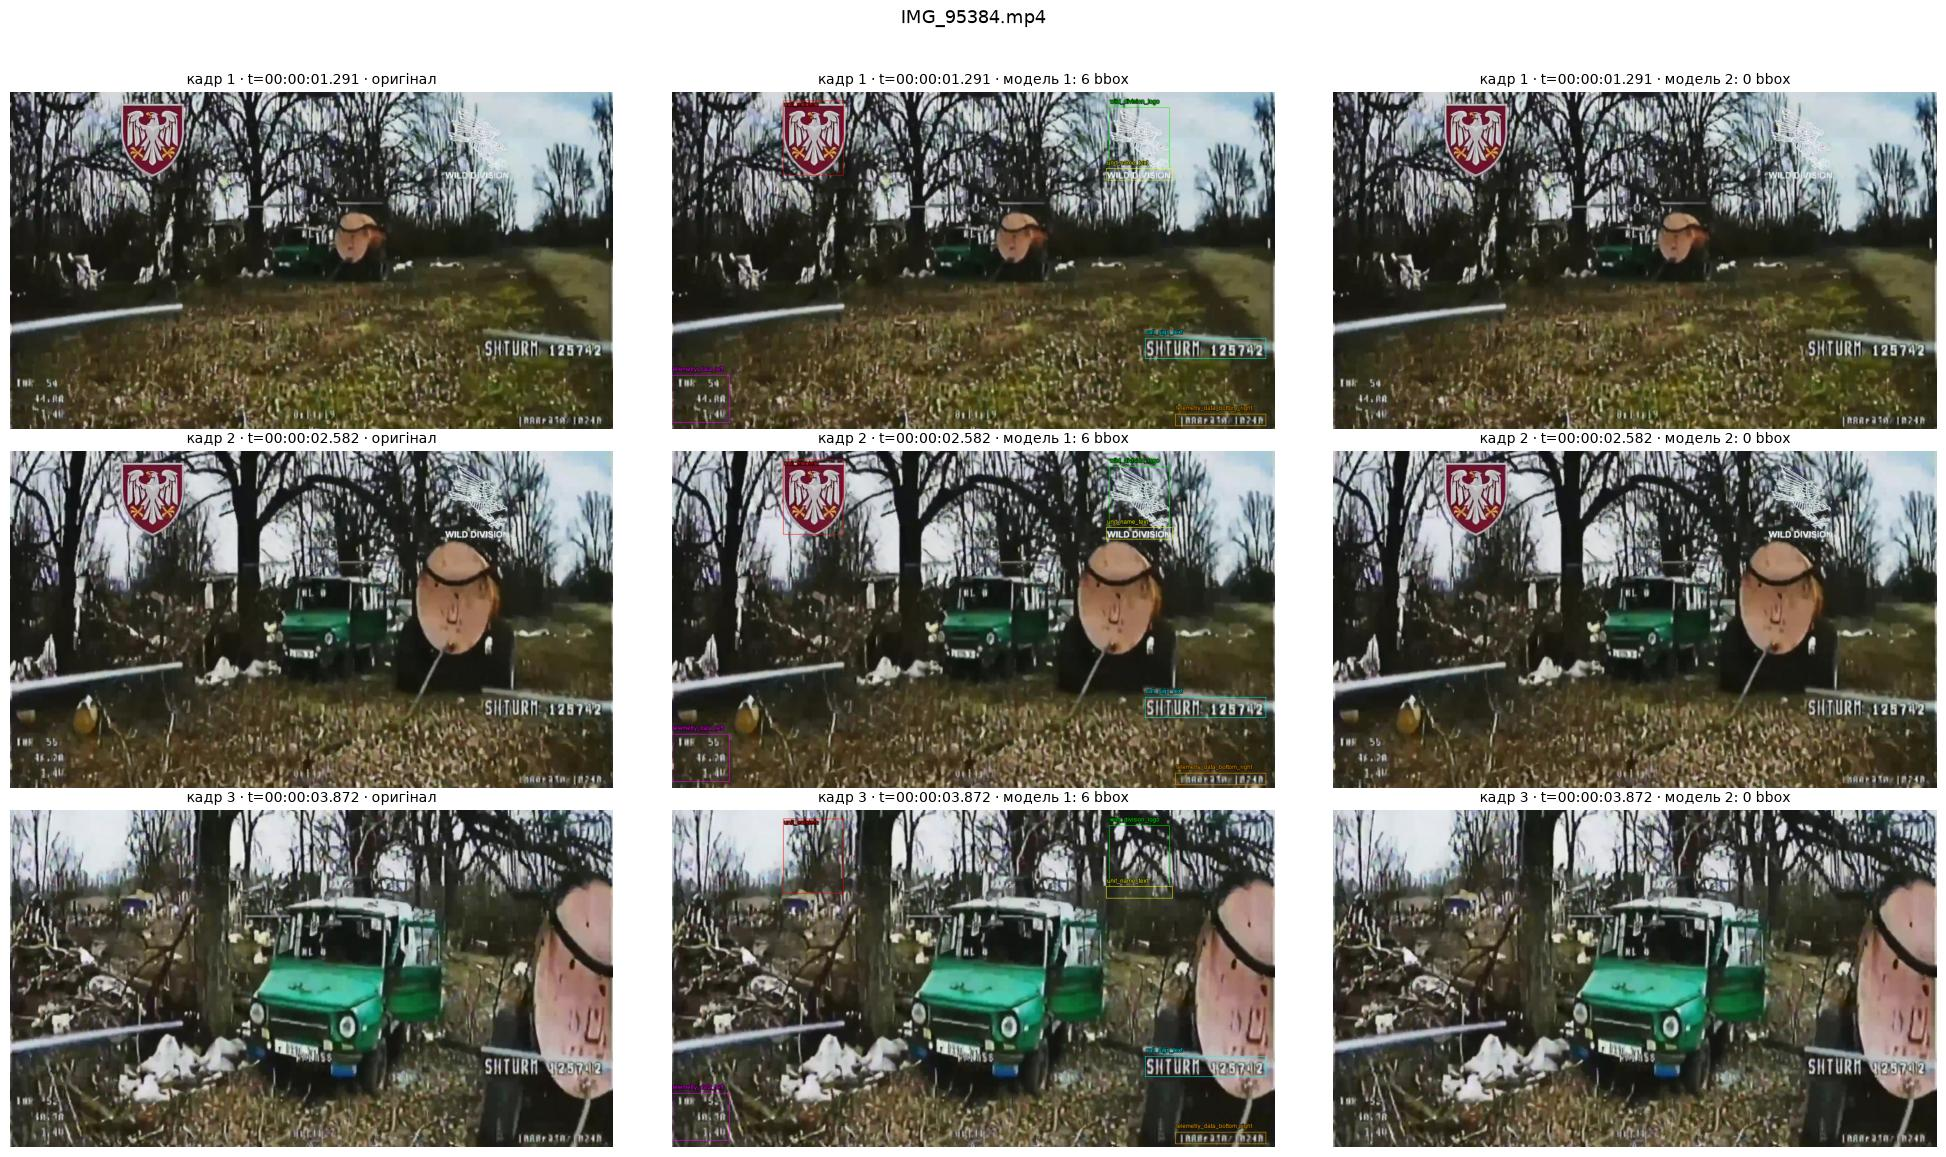

📋 словник моделі 2 без all-null ключів: 0 з 25 ключів


'(усі ключі null)'


##############################################################################################################
🎬 r_combatfootage..1.mp4 · bbox: модель 1 = 31, модель 2 = 7 · ран м1 #0, ран м2 #0 · повний час пайплайну 292.7 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,90.09,0.001973
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,202.08,0.007765
разом (м1 + м2),,2,2,292.17,0.009738


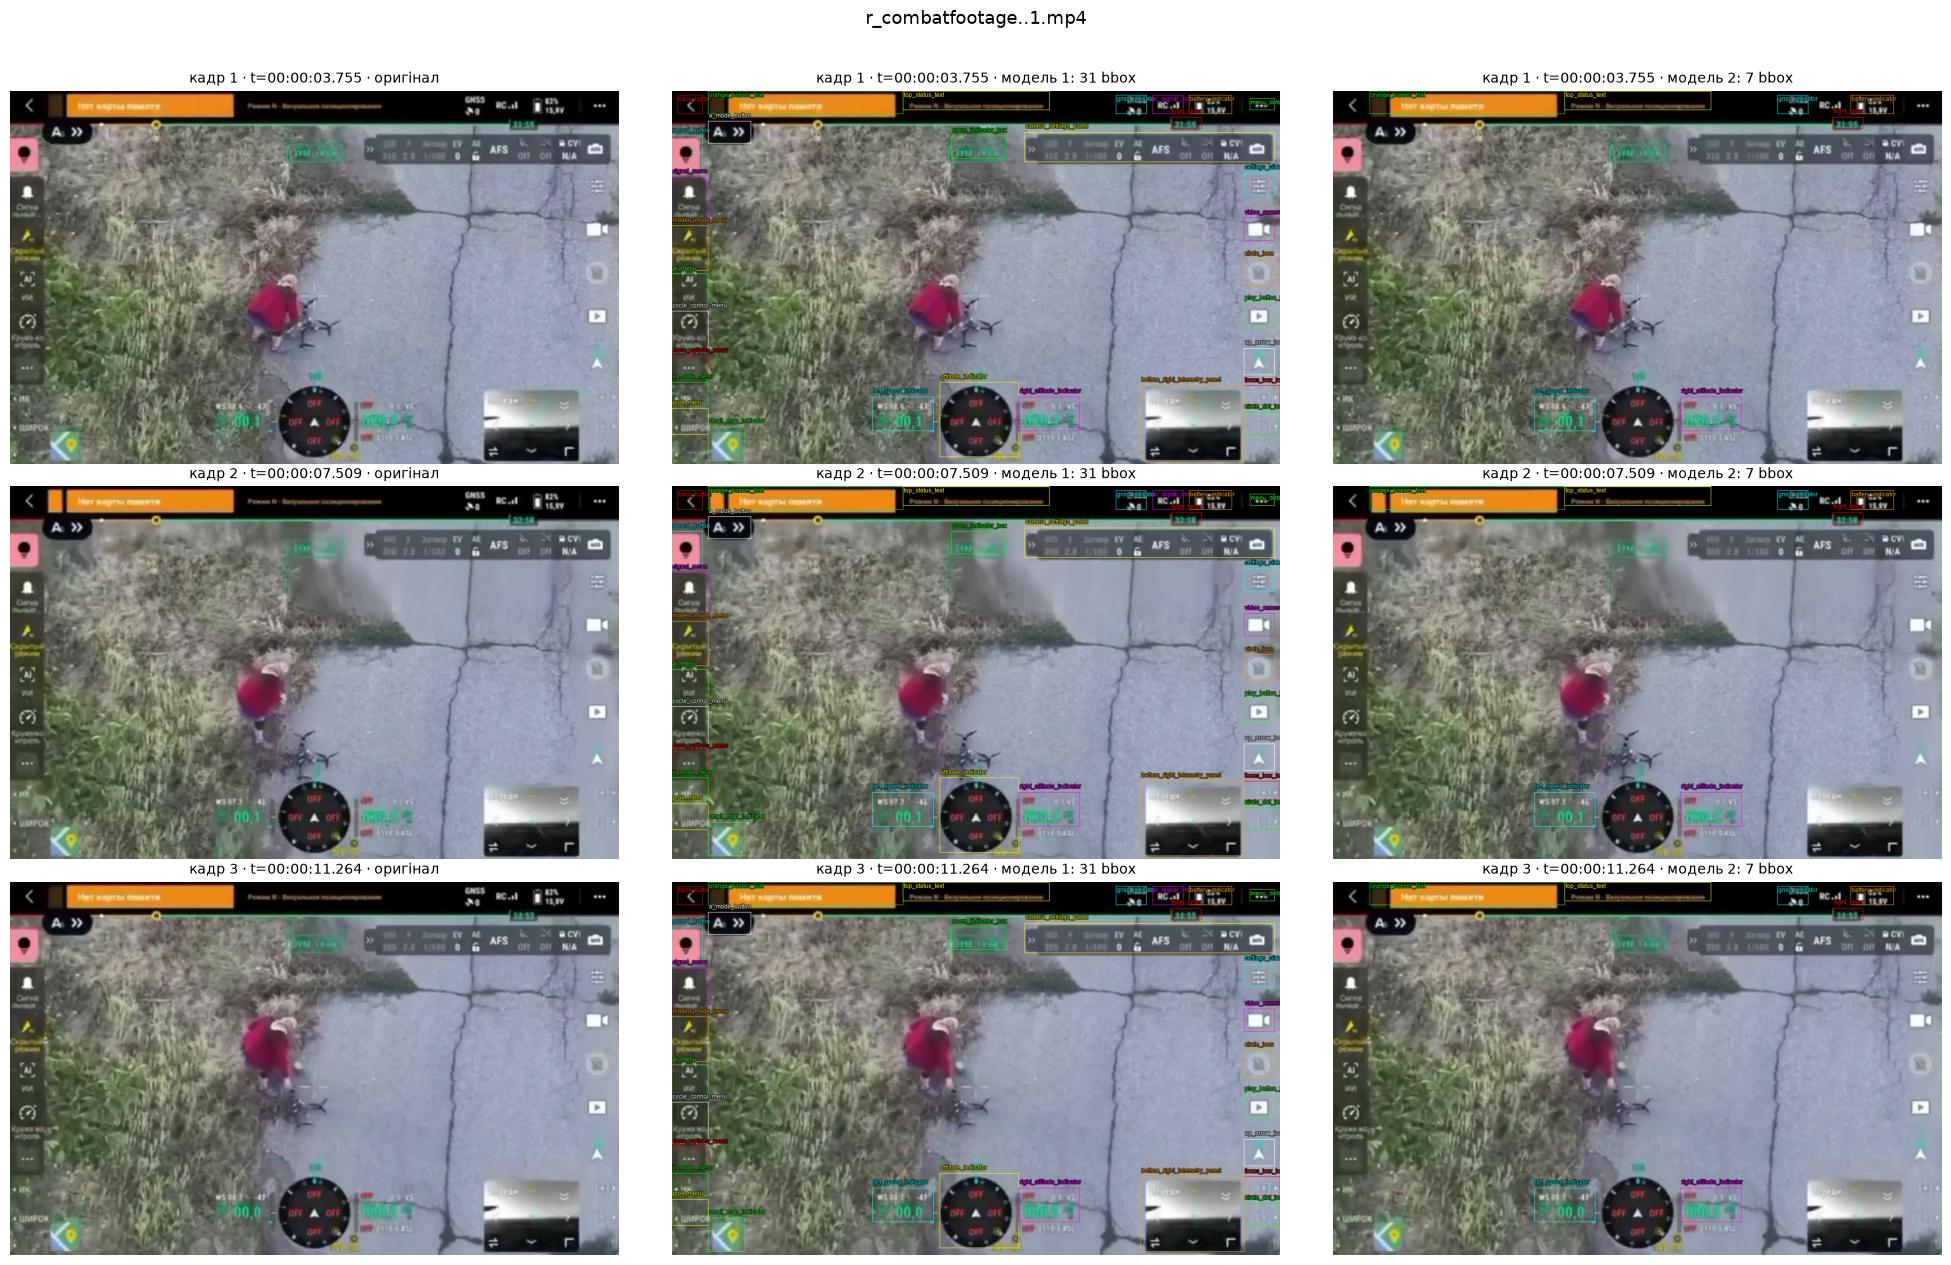

📋 словник моделі 2 без all-null ключів: 9 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
gps_status,3D,3D,3D,gnss_indicator
altitude,0110 ASL,0110 ASL,0110 ASL,right_altitude_indicator
altitude_reference,ASL,ASL,ASL,right_altitude_indicator
speed,00.1,00.1,00.0,left_speed_indicator
vertical_speed,0 VS,0 VS,0 VS,right_altitude_indicator
flight_time,31:59,32:00,32:02,flight_timer
flight_mode,N,N,N,top_status_text
battery_voltage,15.0V,15.0V,15.0V,battery_indicator
warnings,Нет карты памяти,Нет карты памяти,Нет карты памяти,orange_banner_text



##############################################################################################################
🎬 rapidsave_com_russian_flag_carrier_advancing_alone_to_vovchansk.mp4 · bbox: модель 1 = 32, модель 2 = 9 · ран м1 #0, ран м2 #0 · повний час пайплайну 224.0 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,95.28,0.002878
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,128.27,0.003985
разом (м1 + м2),,2,2,223.55,0.006863


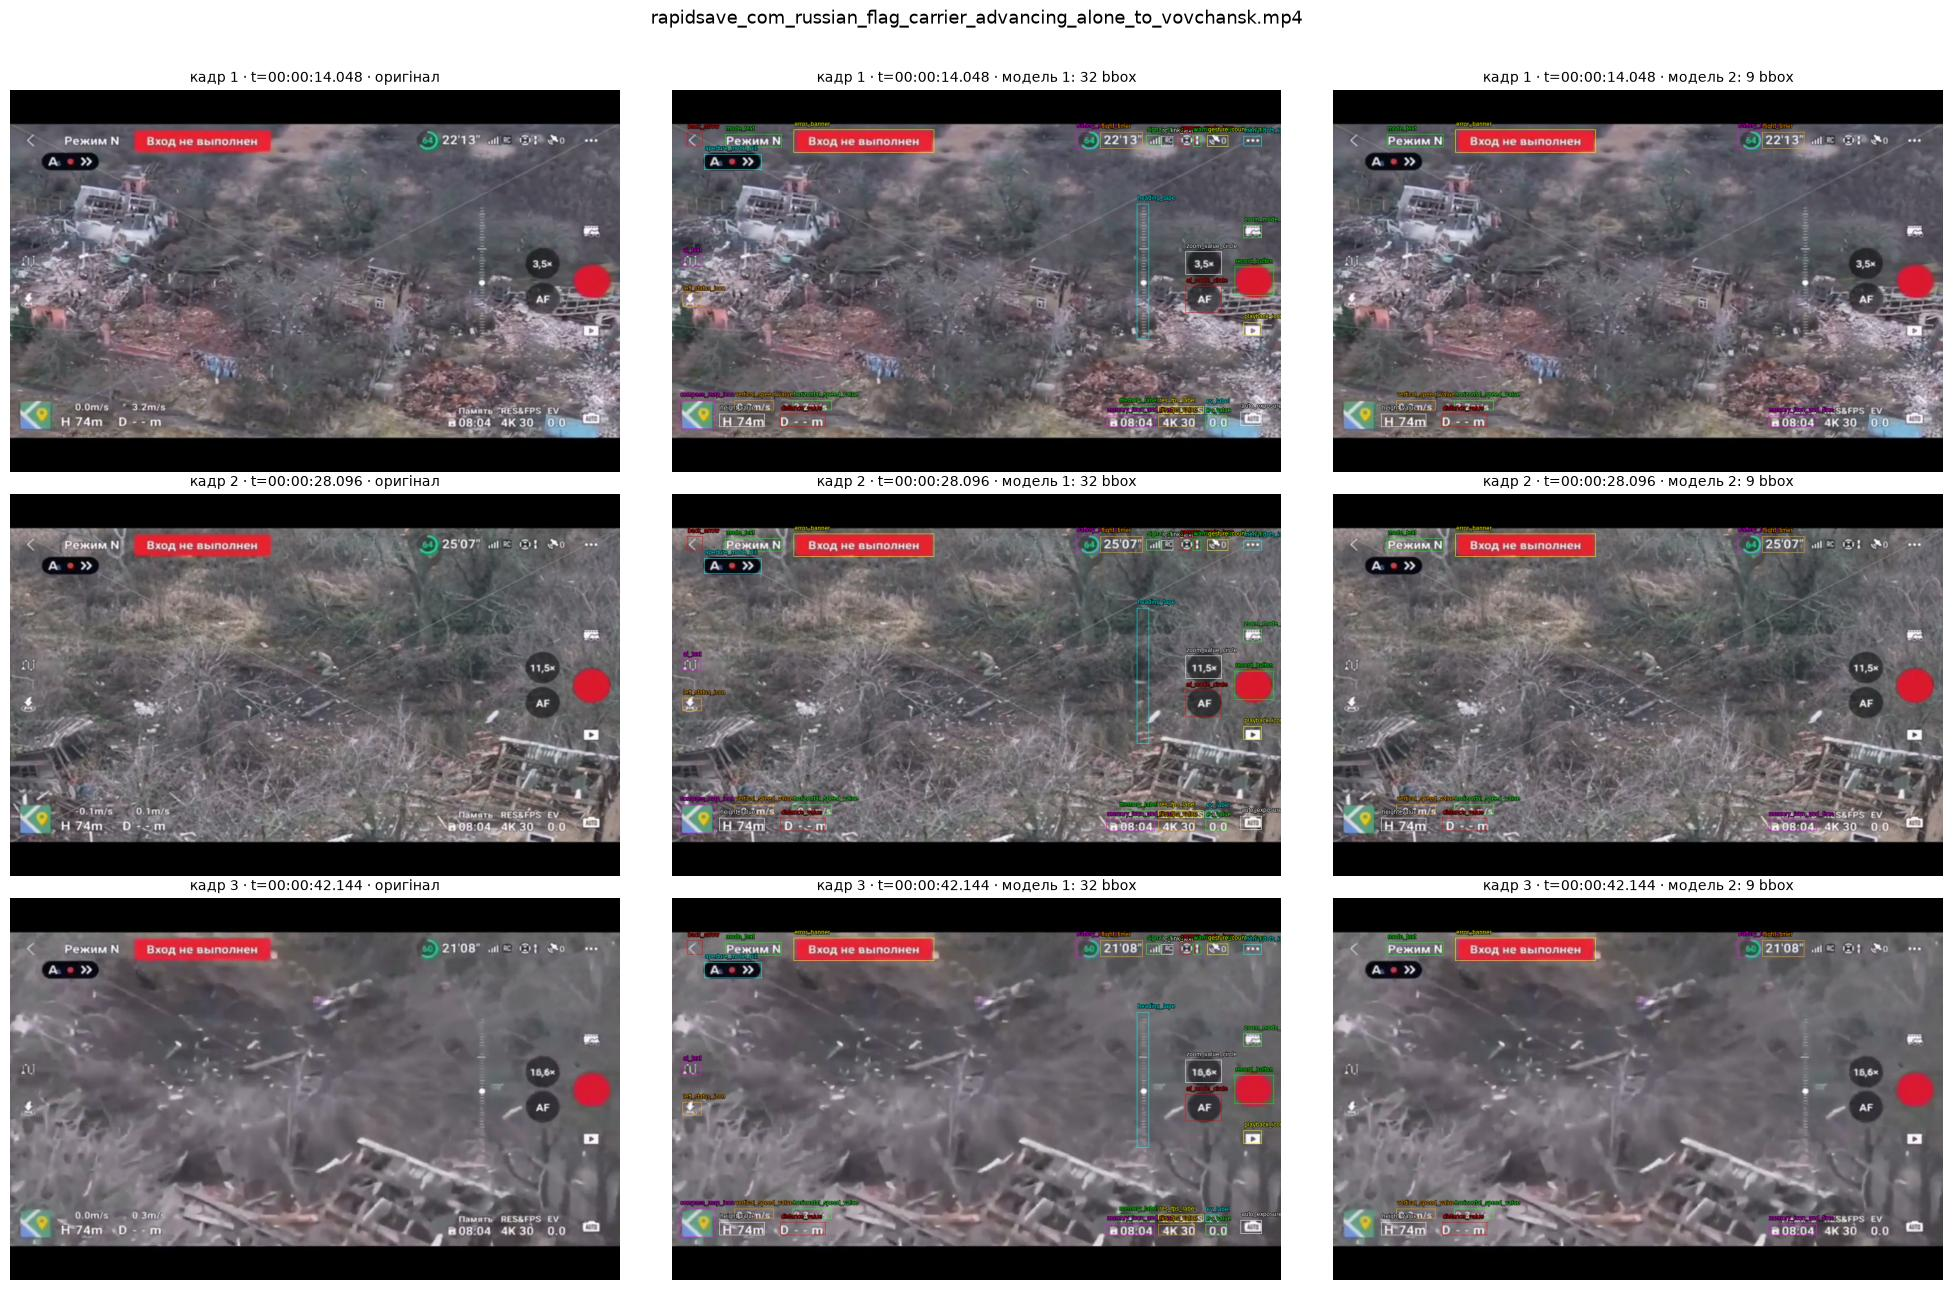

📋 словник моделі 2 без all-null ключів: 9 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
altitude,H 74m,H 74m,H 74m,height_value
ground_speed,0.2 m/s,0.1 m/s,0.2 m/s,horizontal_speed_value
vertical_speed,0 m/s,0 m/s,0 m/s,vertical_speed_value
distance_to_home,D - - m,D - - m,D - - m,distance_value
flight_time,"22'13""","25'07""","21'08""",flight_timer
osd_timer,08:04,08:04,08:04,memory_icon_and_time
flight_mode,Режим N,Режим N,Режим N,mode_text
battery_remaining_pct,64,64,60,battery_level_circle
warnings,Вход не выполнен,Вход не выполнен,Вход не выполнен,error_banner



##############################################################################################################
🎬 video_2026-09-28_19-40-381.mp4 · bbox: модель 1 = 5, модель 2 = 1 · ран м1 #0, ран м2 #0 · повний час пайплайну 87.0 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,66.48,0.000994
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,20.11,0.000743
разом (м1 + м2),,2,2,86.59,0.001737


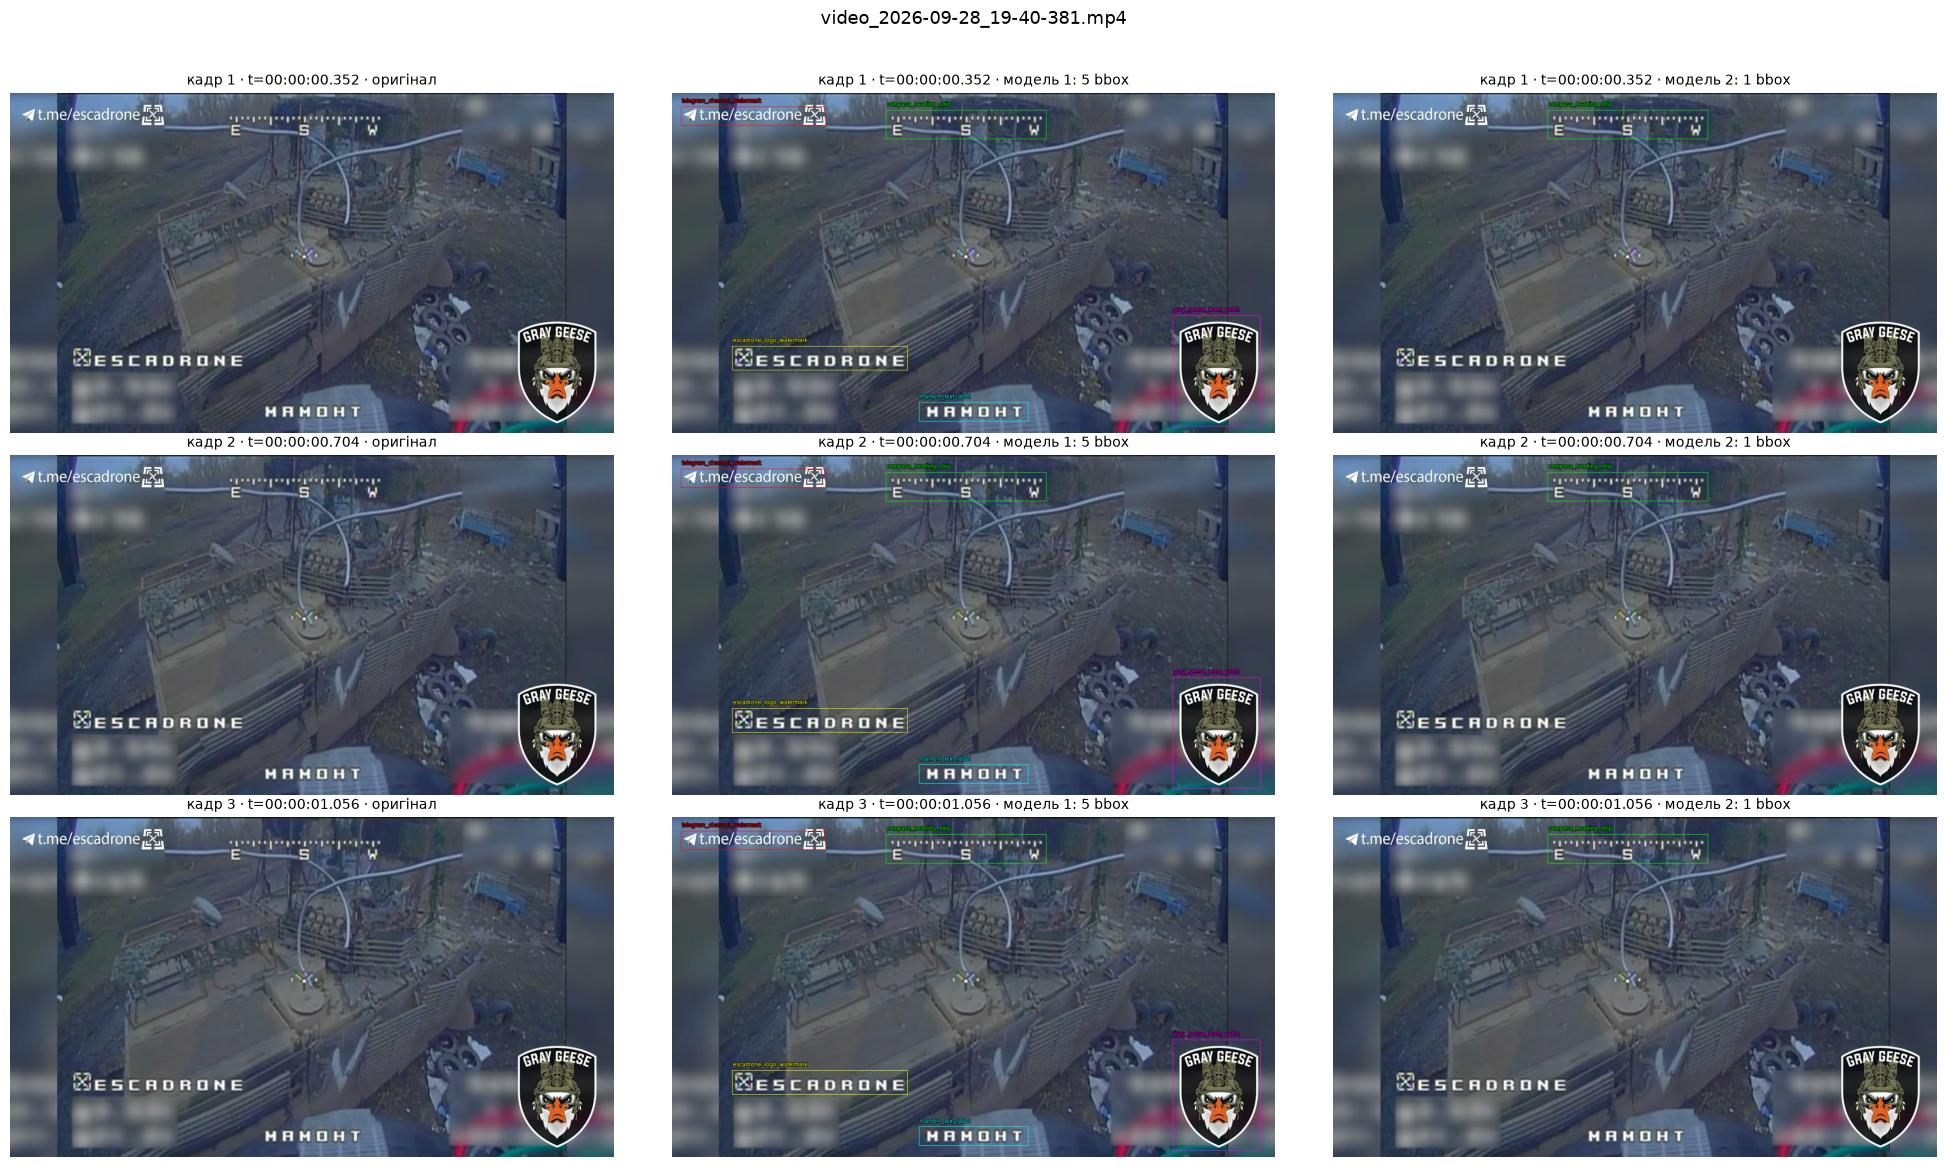

📋 словник моделі 2 без all-null ключів: 1 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
heading,180°,180°,180°,compass_heading_strip



##############################################################################################################
🎬 video_2026-09-28_19-40-382.mp4 · bbox: модель 1 = 7, модель 2 = 2 · ран м1 #0, ран м2 #0 · повний час пайплайну 116.8 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,61.91,0.002243
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,54.51,0.001697
разом (м1 + м2),,2,2,116.42,0.003940


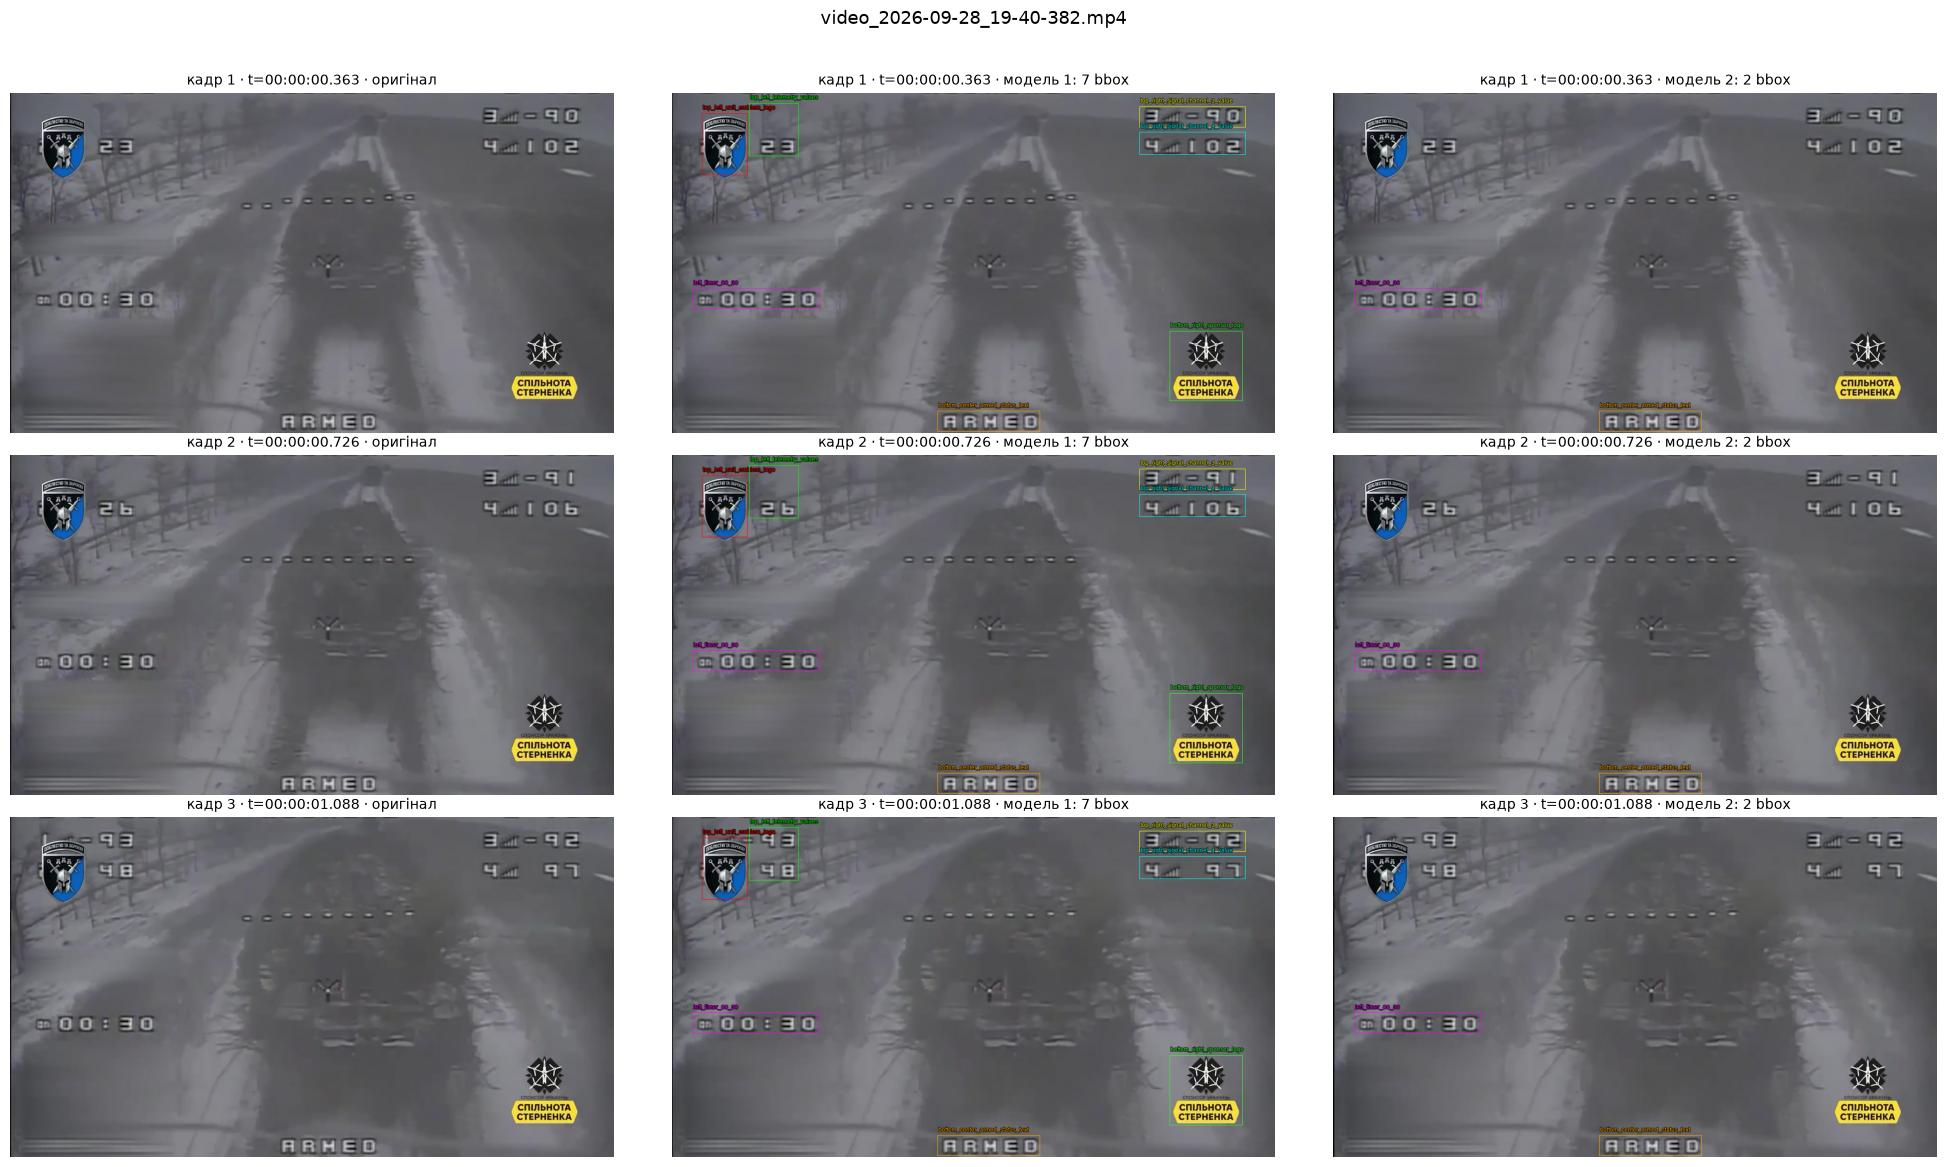

📋 словник моделі 2 без all-null ключів: 2 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
osd_timer,00:30,00:30,00:30,left_timer_00_30
armed,ARMED,ARMED,ARMED,bottom_center_armed_status_text



##############################################################################################################
🎬 video_2026-09-28_19-40-383.mp4 · bbox: модель 1 = 5, модель 2 = 4 · ран м1 #0, ран м2 #0 · повний час пайплайну 153.7 с


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),1,1,37.01,0.001688
модель 2 (значення),qwen/qwen3.8-flash (low),1,1,116.32,0.003536
разом (м1 + м2),,2,2,153.33,0.005224


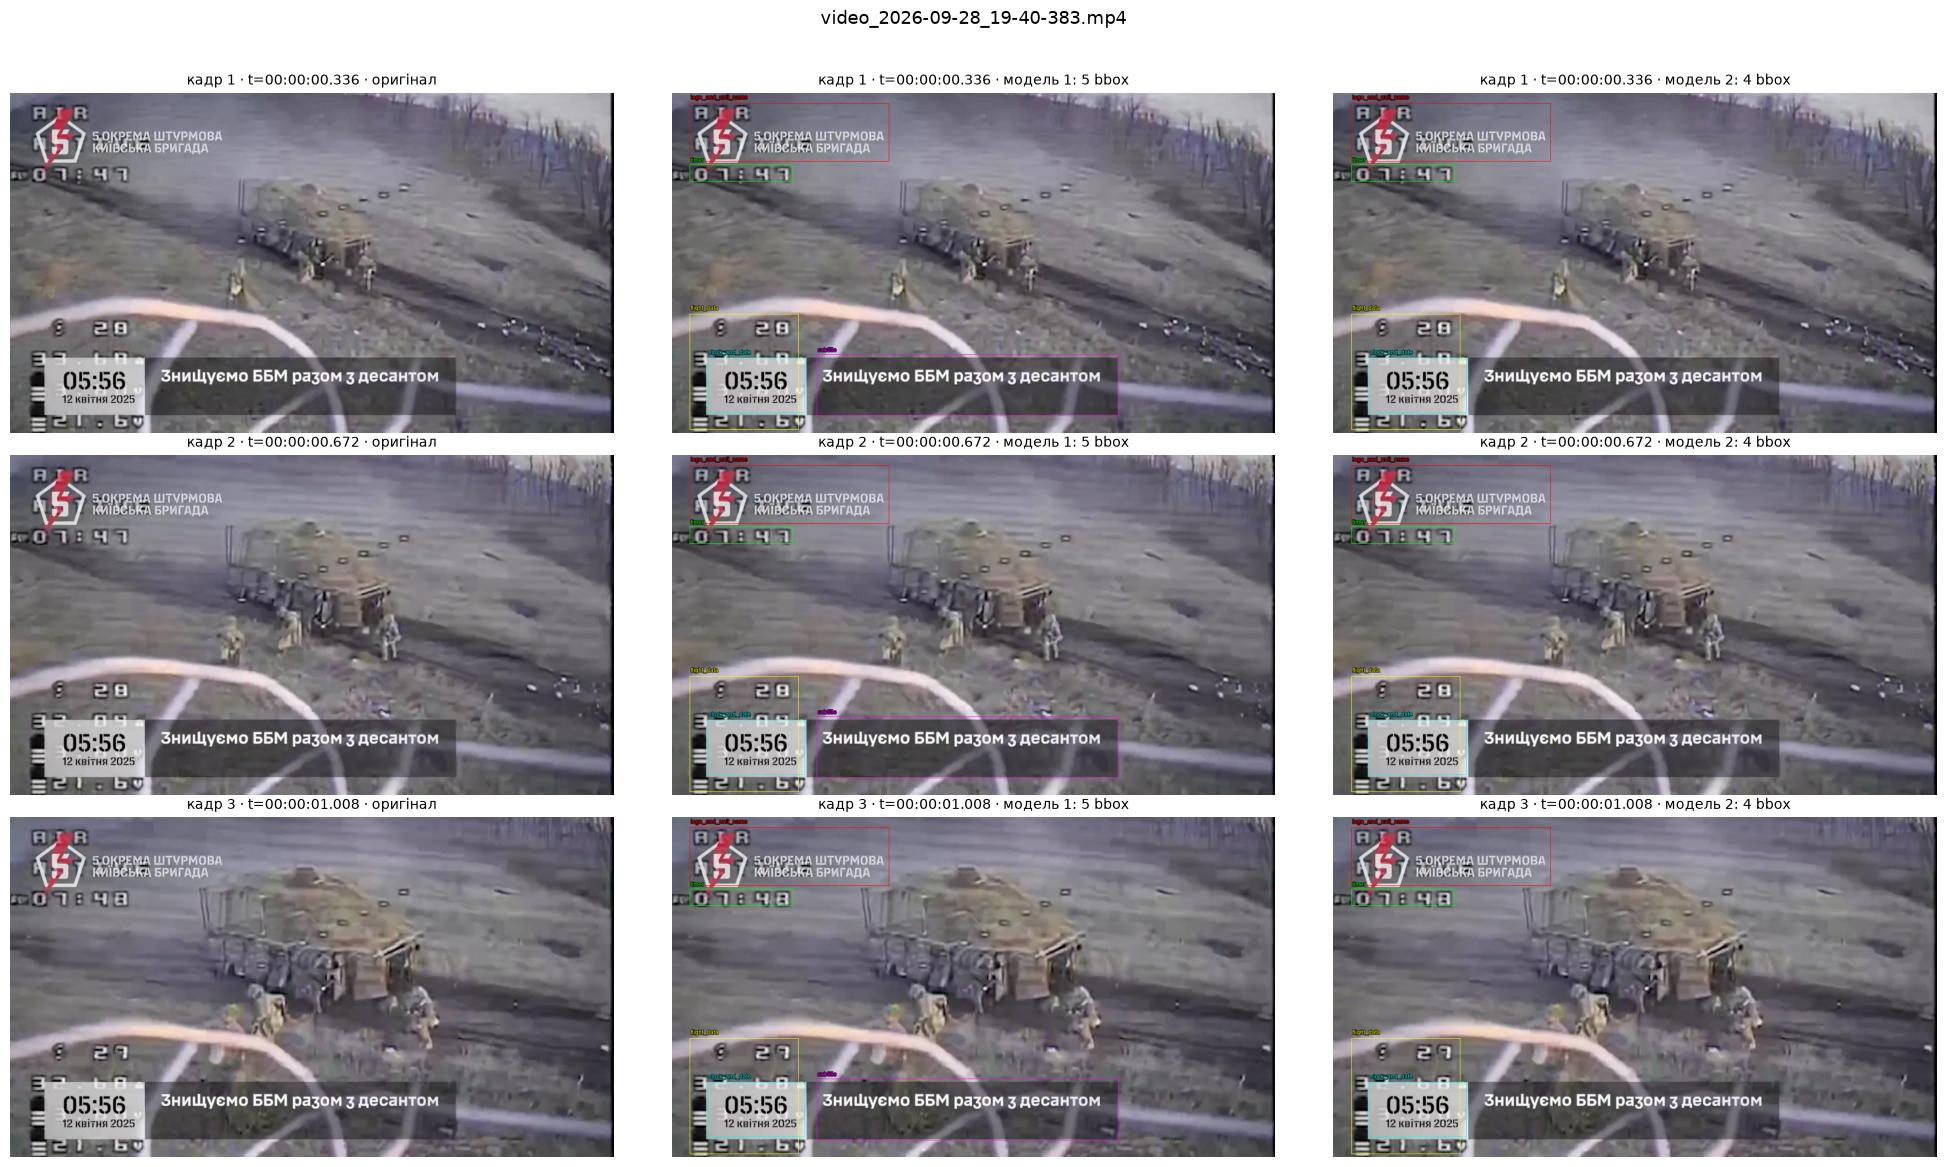

📋 словник моделі 2 без all-null ключів: 6 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
gps_satellites_count,28,28,27,flight_data
osd_date,12 квітня 2025,12 квітня 2025,12 квітня 2025,clock_and_date
osd_clock_time,05:56,05:56,05:56,clock_and_date
osd_timer,07:47,07:47,07:48,timer
flight_mode,AIR,AIR,AIR,logo_and_unit_name
battery_voltage,21.6,21.6,21.6,flight_data


In [3]:
from osd.viz_results import show_results

for video in videos:
    if video not in results:
        print(f"\n❌ {video}: немає результату")
        continue
    print("\n" + "#" * 110)
    show_results(results[video])